**MOST RECENT VERSION OF THIS FILE, CHECK GITHUB FOR PROGRESS!!**

In [1]:
import symlib

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors

import numpy as np
import os

import scipy
from scipy import stats
from scipy.optimize import curve_fit
from scipy.stats import linregress

## Global variables:
*These globals are used by every function below --> this cell MUST be run before anything else*

In [33]:
## GLOBALS:
base_dir = "C:/Users/steph/Symphony"                           ## base directory, points to the container folder where the Symphony data files are

## list of suites to be analyzed
#suite_list = ["MWest", "SymphonyCluster"]
suite_list = ["SymphonyLMC", "SymphonyMilkyWay", "MWest", "SymphonyGroup", "SymphonyLCluster", "SymphonyCluster"]
#suite_list = ["SymphonyLMC", "SymphonyMilkyWay", "MWest", "EDEN_MilkyWay_8K", "SymphonyGroup", "SymphonyLCluster", "SymphonyCluster"]

## colors for confidence band, individual hosts, etc
colors = {"SymphonyLMC": "tab:purple",
          "SymphonyMilkyWay": "tab:blue",
          "MWest": "black",
          "EDEN_MilkyWay_8K": "#5098f2",
          "SymphonyGroup": "tab:green",
          "SymphonyLCluster": "tab:orange",
          "SymphonyCluster": "tab:red"}

## colors for mean lines
avg_colors = {"SymphonyLMC": (102/225, 0/255, 110/255),
              "SymphonyMilkyWay": (7/255, 0/255, 110/255),
              "MWest": (0, 0, 0),
              "EDEN_MilkyWay_8K": (37/255, 107/255, 194/255),
              "SymphonyGroup": (22/255, 112/255, 0/255),
              "SymphonyLCluster": (163/255, 90/255, 2/255),
              "SymphonyCluster": (128/255, 3/255, 3/255)}

labels = {"SymphonyLMC": "SymphonyLMC",
          "SymphonyMilkyWay": "SymphonyMilkyWay",
          "MWest": "MWest",
          "EDEN_MilkyWay_8K": "EDEN_MilkyWay_8K",
          "SymphonyGroup": "SymphonyGroup",
          "SymphonyLCluster": "SymphonyLCluster",
          "SymphonyCluster": "SymphonyCluster"}

## suite-to-model mapping
mah_fit_model = {"SymphonyLMC": "wechsler",
                 "SymphonyMilkyWay": "wechsler",
                 "MWest": "wechsler",
                 "EDEN_MilkyWay_8K": "wechsler",
                 "SymphonyGroup": "wechsler",
                 "SymphonyLCluster": "mcbride",
                 "SymphonyCluster": "mcbride"}

## maximum x-axis extents for SHMFs
x_max_shmf = {"SymphonyLMC": 2e11,
              "SymphonyMilkyWay": 2e12,
              "MWest": 2e12,
              "EDEN_MilkyWay_8K": 2e12,
              "SymphonyGroup": 2e13,
              "SymphonyLCluster": 2e14,
              "SymphonyCluster": 2e15}

min_particles: int = 300    ## minimum number of particles for a halo to be considered "well-resolved"
z_max: float = 16.0         ## maximum redshift to keep (inclusive)

## MAH parameters:
redshift_ticks = [16, 8, 4, 2, 1, 0.5, 0.25]                   ## ticks and labels for when x_axis = "redshift"
redshift_labels = ["16", "8", "4", "2", "1", "0.5", "0.25"]
z_xlim = (16.0, 0.05)
mah_host_lw = 0.5                       ## per-host linewidth
mah_host_alpha = 0.15                   ## host alpha (opacity)
mah_avg_lw = 1.25                       ## average linewidth
mah_confidence_band_alpha = 0.25        ## alpha (opacity) of the 16-84% confidence band

## SHMF parameters:
redshifts_shmf: list[float] = [2.0, 1.0, 0.5, 0.25, 0.1, 0.0]
#redshifts_shmf: list[float] = [0.0]
n_bins: int = 50                                               ## number of mass bins
m_max: float = 1e15                                            ## mass of the highest mass bin
shmf_host_lw = 0.5                                             ## same as for MAHs, just for SHMFs
shmf_host_alpha = 0.15
shmf_avg_lw = 1.25
shmf_confidence_band_alpha = 0.25

## Mass accretion histories:
* A "mass accretion history" is the mass of the subhalo as a function of time (snapshot, scale factor, redshift, cosmic time, etc).
* Below we focus on HOST mass accretion histories
* A 300 particle cut and a "survival cut" are applied, to exclude any times where the host was not well-resolved or well-formed
* Functionality is separated into several helper functions, a "dataloader" which loads all the relevant data in once, and then some "statistics" functions and a "plotter" function.
* All of this will be combined with the other plots into one "master" function eventually, where a series of toggle-able parameters control what plot comes out.

Starting with the dataloader for the mass accretion histories:

All the data needed to create mass accretion histories for all the suites is read in and formatted as a dictionary

In [30]:
## MAHs dataloader --> reading in data for creating MAHs for all suites in Symphony
## inputs: base_dir, suite_list

## output will be a dictionary, with indexable (key, value) pairs
## the dataloader function will be built on a per-suite basis for simplicity


## HELPER FUNCTIONS:

## build_z_mask returns a numpy array of timesteps we want to keep
def build_z_mask(scale_factors: np.ndarray, suite: str):
    
    redshifts = (1.0 / scale_factors) - 1.0
    mask = redshifts <= z_max
    if suite == "MWest":
        ## MWest behavior is different for some reason?
        mask &= scale_factors <= 1.0
        
    return mask

## due to the masking, lists may be different sizes
## so we need to pad the shorter arrays with NaN until they all match the length of the longest one
## nan_padding returns a numpy array of left-padded so that all are the same length as the longest array,
## then stacks them into a 2D array with shape (n_arrays, length)
## left-padding aligns all the arrays at their z = 0 snapshot
def nan_padding(arrays: list[np.ndarray], length: int):
    
    padded = [np.concatenate([np.full(length - len(a), np.nan), a]) for a in arrays]
    
    return np.vstack(padded)


## per-suite dataloader; loads mass accretion history information for every host in a given suite
## inputs: base_dir (string), suite (string),
##         min_mass_resolution_limit (int, usually 300 particles), z_max (float, this is somewhat arbitrarily chosen),
##         verbose (bool, controls whether progress print statements are on or off)
## outputs dict with keys:
##         scale_factors        # np.ndarray, shape (T,)   – reference time axis
##         redshifts            # np.ndarray, shape (T,)
##         masses               # np.ndarray, shape (N, T)  – NaN where unresolved
##         host_scale_factors   # list[np.ndarray]       – per-host, unpadded
##         host_masses          # list[np.ndarray]       – per-host, unpadded
##         particle_mass        # float  – mp [M_sun/h] from first host
##         n_hosts              # int
##         suite                # str

def load_MAH_suite_data(base_dir: str, suite: str, min_particles: int = min_particles, z_max: float = z_max, verbose: bool = True):
    
    n_hosts = symlib.n_hosts(suite)                 ## get the # of hosts (individual simulations in each folder)

    ## initializing empty lists to be filled later
    host_masses: list[np.ndarray] = []
    host_scale_factors: list[np.ndarray] = []
    particle_mass = None

    ## tracking any hosts that failed to load
    skipped_hosts: list[int] = []

    ## looping over hosts in a particular suite
    for i_host in range(n_hosts):
        if verbose:
            print(f"Loading host {i_host + 1} in suite {suite}", end = "\r", flush = True)

        try:
            sim_dir = symlib.get_host_directory(base_dir, suite, i_host)                ## getting the full directory to the host data
            h, hist = symlib.read_subhalos(sim_dir)                                     ## reading in the Symfind halo finder data

            ## storing particle mass for the first host (identical across a suite)
            if particle_mass is None:
                params = symlib.simulation_parameters(sim_dir)                          ## getting simulation parameters used in this suite
                particle_mass = float(params["mp"])                                     ## getting "macro-particle" mass used in this suite

            scale_factors = symlib.scale_factors(sim_dir)                               ## reading in per-host scale factors (resolves problems with masking)
            z_mask = build_z_mask(scale_factors, suite)
            scale_factors = scale_factors[z_mask]                                       ## applying the redshift cut

            ## getting host properties (host is always index 0)
            host_mass = np.array(h["mvir"][0])                                          ## host virial mass for all snapshots
            host_ok = np.array(h["ok"][0])                                              ## all snapshots where the host was properly identified by Symfind
            mass_cut = min_particles * particle_mass                                    ## 300 particles mass resolution limit

            ## applying the 300 particle resolution cut and the "ok" survival cut:
            ## keeping only snapshots where the host is "ok" AND "well-resolved" (at or above 300 particles)
            ## host_mass_masked *removes* these subhalos by replacing them with NaN
            host_mass_masked = np.where((host_mass < mass_cut) | ~host_ok, np.nan, host_mass)[z_mask]
            host_masses.append(host_mass_masked)
            host_scale_factors.append(scale_factors)

        except Exception as e:
            skipped_hosts.append(i_host)

            if verbose:
                print(f"\nSkipped host {i_host} in suite {suite}: {type(e).__name__}: {e}")

            continue

    if verbose:
        print()

        if skipped_hosts:
            print(f"Skipped {len(skipped_hosts)} corrupted host(s) in {suite}: {skipped_hosts}")

    ## use the host with the most snapshots as the reference time axis:
    ref_idx = int(np.argmax([len(s) for s in host_scale_factors]))
    ref_scale = host_scale_factors[ref_idx]
    max_len = len(ref_scale)
    masses_2D = nan_padding(host_masses, max_len)
    ref_redshift = (1.0 / ref_scale) - 1.0

    return {"suite": suite,
            "n_hosts": len(host_masses),              ## changing n_hosts to reflect only successfully loaded hosts
            "particle_mass": particle_mass,
            "scale_factors": ref_scale,               ## shape (T, )
            "redshifts": ref_redshift,                ## shape (T, )
            "masses": masses_2D,                      ## shape (N, T)
            "host_scale_factors": host_scale_factors, ## shape (N, T)
            "host_masses": host_masses,
            "skipped_hosts": skipped_hosts}


## function to automatically load all suites in suite_list, using load_MAH_suite_data:
def load_all_MAH_data(base_dir: str, suites = list[str], min_particles: int = min_particles, z_max: float = z_max, verbose: bool = True):
    
    if suites is None:
        suites = suite_list   ## defaults to the global string
    all_MAH_data: dict[str, dict] = {}
    
    for index, suite in enumerate(suites):
        all_MAH_data[suite] = load_MAH_suite_data(base_dir, suite, min_particles = min_particles, z_max = z_max, verbose = verbose)
        
    return all_MAH_data

## entrypoint to load the data
MAH_data = load_all_MAH_data(base_dir, suite_list)

Loading host 39 in suite SymphonyLMC
Loading host 45 in suite SymphonyMilkyWay
Loading host 20 in suite MWest
Loading host 49 in suite SymphonyGroup
Loading host 33 in suite SymphonyLCluster
Loading host 81 in suite SymphonyCluster


The data collected by the dataloader is then passed into the "Statistics" and "Plotting" functions:

C:\Users\steph\AppData\Local\Temp\ipykernel_2292\2929991954.py:15: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(masses, axis = 0)              # (T,)
C:\Users\steph\AppData\Local\Temp\ipykernel_2292\2929991954.py:16: RuntimeWarning: All-NaN slice encountered
  median = np.nanmedian(masses, axis = 0)          # (T,)
C:\Users\steph\miniconda3\envs\dm-analysis-env\lib\site-packages\numpy\lib\_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\steph\miniconda3\envs\dm-analysis-env\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


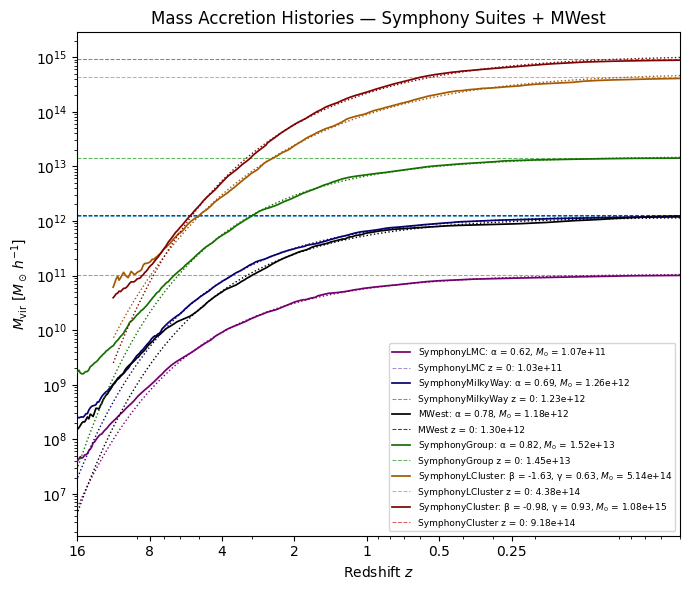

In [31]:
## STATISTICS + PLOTTER:

## STATISTICS: computes mean, median, standard deviation and 16-84% confidence band
def compute_MAH_stats(suite_data: dict):

    masses = suite_data["masses"]                    # (N, T)
    scale_factors = suite_data["scale_factors"]      # (T,)
    redshifts = suite_data["redshifts"]              # (T,)

    ## check that at least one host is well resolved at a particular timestep:
    n_resolved = np.sum(~np.isnan(masses), axis = 0) # (T,)         ## ~np.isnan gives all where the value is NOT NaN
    valid_mask = n_resolved > 0                      # (T,) bool

    ## using nan-sensitive functions
    mean = np.nanmean(masses, axis = 0)              # (T,)
    median = np.nanmedian(masses, axis = 0)          # (T,)
    std = np.nanstd(masses, axis = 0)                # (T,)
    p16 = np.nanpercentile(masses, 16, axis = 0)     # (T,)
    p84 = np.nanpercentile(masses, 84, axis = 0)     # (T,)

    # use the last snapshot where at least one host is resolved,
    # rather than blindly taking index [-1] which may be all-NaN.
    valid_indices = np.where(valid_mask)[0]
    final_mass = float(mean[valid_indices[-1]]) if len(valid_indices) > 0 else np.nan

    return {"suite": suite_data["suite"],
            "scale_factors": scale_factors,
            "redshifts": redshifts,
            "mean": mean,
            "median": median,
            "std": std,
            "p16": p16,
            "p84": p84,
            "final_mass": final_mass,
            "valid_mask": valid_mask,
            "n_resolved": n_resolved}

## function to run the statistics over all suites
def compute_all_MAH_stats(all_MAH_data: dict[str, dict]):
    
    all_MAH_stats = {suite: compute_MAH_stats(suite_data) for suite, suite_data in all_MAH_data.items()}
    
    return all_MAH_stats

#####################################################################################################################

## FITTING:

## simple exponential MAH model: M(z) = M0*exp(-alpha*z) [Wechsler+ 2002 form] 
def mah_wechsler_model(z, M0, alpha):
    
    return M0*np.exp(-alpha*z)

## power-law correction
def mah_mcbride_model(z, M0, beta, gamma):
    return M0 * (1 + z)**beta * np.exp(-gamma * z)

## fit M(z) = M0*exp(-alpha*z) to the MEAN MAH of the suite
## returns dict with keys:
## M0: fitted z = 0 mass
## alpha: fitted formation rate parameter
## x_fit: x-values for plotting the fit curve
## y_fit: y-values for plotting the fit curve
## popt: raw [M0, alpha]
## pcov: covariance matrix
def fit_mah_wechsler(suite_stats, x_axis):

    valid = suite_stats["valid_mask"]
    x = suite_stats["redshifts"][valid]     ## always fit in redshift space, regardless of what the toggle is set to
    y = suite_stats["mean"][valid]

    ## restrict fit to z <= 6 and where mean is finite and well-sampled
    z_fit_mask = (x <= 6.0) & np.isfinite(y)
    x_fit_data = x[z_fit_mask]
    y_fit_data = y[z_fit_mask]

    ## initial guess: M0 = final mass, alpha = 0.5
    ## fit in log-mass space
    ## log(M) = log(M0) - alpha * z  -->  linear regression
    log_y = np.log(y_fit_data)
    p0 = [np.log(suite_stats["final_mass"]), 0.5]
    popt, pcov = curve_fit(lambda z, logM0, alpha: logM0 - alpha * z, x_fit_data, log_y, p0 = p0, maxfev = 10000)
    logM0, alpha = popt
    M0 = np.exp(logM0)

    ## generate smooth curve for plotting
    ## spans the full x-axis range
    x_smooth = np.linspace(0, suite_stats["redshifts"][suite_stats["valid_mask"]].max(), 500)
    y_smooth = mah_wechsler_model(x_smooth, M0, alpha)

    ## convert x_smooth to scale factor if required by toggle
    x_plot = x_smooth if x_axis == "redshift" else (1.0/(x_smooth + 1.0))

    return {"M0": M0,
            "alpha": alpha,
            "x_fit": x_plot,
            "y_fit": y_smooth,
            "popt": popt,
            "pcov": pcov}

def fit_mah_mcbride(suite_stats, x_axis):

    valid = suite_stats["valid_mask"]
    x = suite_stats["redshifts"][valid]
    y = suite_stats["mean"][valid]

    ## restrict fit to z <= 6 and where mean is finite and well-sampled
    z_fit_mask = (x <= 6.0) & np.isfinite(y)
    x_fit_data = x[z_fit_mask]
    y_fit_data = y[z_fit_mask]

    ## fit in log-space: log(M) = log(M0) + beta*log(1+z) - gamma*z
    log_y = np.log(y_fit_data)
    log_1pz = np.log(1 + x_fit_data)

    p0 = [np.log(suite_stats["final_mass"]), 0.5, 0.5]
    popt, pcov = curve_fit(lambda z, logM0, beta, gamma: logM0 + beta * np.log(1 + z) - gamma * z,
                           x_fit_data, log_y, p0 = p0, maxfev = 10000)
    logM0, beta, gamma = popt
    M0 = np.exp(logM0)

    ## x_smooth spans the full x-axis range
    x_smooth = np.linspace(0, suite_stats["redshifts"][suite_stats["valid_mask"]].max(), 500)
    y_smooth = mah_mcbride_model(x_smooth, M0, beta, gamma)
    x_plot = x_smooth if x_axis == "redshift" else (1.0 / (x_smooth + 1.0))

    return {"M0": M0,
            "beta": beta,
            "gamma": gamma,
            "x_fit": x_plot,
            "y_fit": y_smooth,
            "popt": popt,
            "pcov": pcov}


def fit_all_mah_wechsler(all_MAH_stats, x_axis):
    return {suite: fit_mah_wechsler(suite_stats, x_axis = x_axis) for suite, suite_stats in all_MAH_stats.items()}

def fit_all_mah_mcbride(all_MAH_stats, x_axis):
    return {suite: fit_mah_mcbride(suite_stats, x_axis = x_axis) for suite, suite_stats in all_MAH_stats.items()}


def fit_mah_suite(suite_stats, suite, x_axis):
    model = mah_fit_model.get(suite, "wechsler")   ## default to wechsler if suite not in dict
    if model == "wechsler":
        return fit_mah_wechsler(suite_stats, x_axis)
    elif model == "mcbride":
        return fit_mah_mcbride(suite_stats, x_axis)

def fit_all_mah(all_MAH_stats, x_axis):
    return {suite: fit_mah_suite(suite_stats, suite, x_axis) for suite, suite_stats in all_MAH_stats.items()}

#####################################################################################################################

## MAIN PLOTTER:

## plotting helpers:

## getting the correct x-axis
def get_xaxis(suite_stats: dict, x_axis: str):
    
    if x_axis == "scale_factor":
        return suite_stats["scale_factors"]
    elif x_axis == "redshift":
        return suite_stats["redshifts"]
    else:
        raise ValueError(f"x_axis must be 'scale_factor' or 'redshift', but got {x_axis!r}")

## configuring axes
def ax_config_MAH(ax: matplotlib.axes.Axes, x_axis: str):
    
    ax.set_yscale("log")
    ax.set_ylabel(r"$M_\mathrm{vir}\ [M_\odot\,h^{-1}]$", fontsize = 10)

    if x_axis == "scale_factor":
        ax.set_xlabel("Scale Factor $a$", fontsize = 10)

    elif x_axis == "redshift":
        ax.set_xscale("log")
        ax.set_xticks(redshift_ticks)
        ax.set_xticklabels(redshift_labels)
        ax.set_xlim(z_xlim)
        ax.set_xlabel(r"Redshift $z$", fontsize = 10)

## plotting per-suite data:
def plot_suite_MAH(ax: matplotlib.axes.Axes, suite: str, suite_data: dict, suite_stats: dict, x_axis: str,
                   show_hosts: bool = True, show_confidence: bool = True, show_fit = False, mah_fits = None):

    color = colors[suite]
    avg_color = avg_colors[suite]
    valid = suite_stats["valid_mask"]
    x = get_xaxis(suite_stats, x_axis)

    ## individual hosts:
    if show_hosts:
        for host_sf, host_mass in zip(suite_data["host_scale_factors"], suite_data["host_masses"]):

            ## each host has its own time axis:
            host_x = host_sf if x_axis == "scale_factor" else ((1.0 / host_sf) - 1.0)
            ax.plot(host_x, host_mass, color = color, lw = mah_host_lw, alpha = mah_host_alpha)

    ## 16-84% confidence band:
    if show_confidence:
        ax.fill_between(x[valid], suite_stats["p16"][valid], suite_stats["p84"][valid], color = color, alpha = mah_confidence_band_alpha)

    ## mean:
    ax.plot(x[valid], suite_stats["mean"][valid], color = avg_color, lw = mah_avg_lw, zorder = 3, label = suite)

    ## exponential fit:
    if show_fit and mah_fits is not None and suite in mah_fits:
        fits = mah_fits[suite]
        ax.plot(fits["x_fit"], fits["y_fit"], color = avg_colors[suite], lw = 1.0, linestyle = ":", zorder = 4)

    ## final mass line:
    fm = suite_stats["final_mass"]
    if np.isfinite(fm):
        ax.axhline(fm, color = colors[suite], linestyle = "--", lw = 0.75, alpha = 0.75, label = f"z = 0 mass: {fm:.2e}")


## adding the option to normalize by the z = 0 mass accretion history:

## computing z = 0 normalized masses:
def compute_normalized_masses(suite_data: dict):
    
    masses = suite_data["masses"].copy()
    z0_masses = masses[:, -1]
    norm_masses = masses / z0_masses[:, np.newaxis]

    return norm_masses

def plot_suite_MAH_normalized(ax: matplotlib.axes.Axes, suite: str, suite_data: dict, suite_stats: dict, x_axis: str,
                              show_hosts: bool, show_confidence: bool = True):

    color = colors[suite]
    avg_color = avg_colors[suite]
    valid = suite_stats["valid_mask"]
    x = get_xaxis(suite_stats, x_axis)
    fm = suite_stats["final_mass"]

    norm_masses = compute_normalized_masses(suite_data)
    norm_mean = np.nanmean(norm_masses, axis = 0)
    norm_p16 = np.nanpercentile(norm_masses, 16, axis = 0)
    norm_p84 = np.nanpercentile(norm_masses, 84, axis = 0)

    ## individual hosts normalized by their own z=0 mass:
    if show_hosts:
        for host_sf, host_mass in zip(suite_data["host_scale_factors"], suite_data["host_masses"]):
            host_x  = host_sf if x_axis == "scale_factor" else ((1.0 / host_sf) - 1.0)
            host_fm = host_mass[-1]
            if np.isfinite(host_fm) and host_fm != 0:
                ax.plot(host_x, host_mass / host_fm, color = color, lw = mah_host_lw, alpha = mah_host_alpha)

    if show_confidence:
        ax.fill_between(x[valid], norm_p16[valid], norm_p84[valid], color = color, alpha = mah_confidence_band_alpha)
    ax.plot(x[valid], norm_mean[valid], color = avg_color, lw = mah_avg_lw, zorder = 3, label = suite)

## putting it all together:
## all_MAH_data = data dictionary from load_all_MAH_data
## all_MAH_stats = data dictionary from compute_all_MAH_stats
## outputs a single-panel figure (or double-panel if "dual" = True)

def plot_all_MAH(all_MAH_data: dict[str, dict], all_MAH_stats: dict[str, dict], suites: list[str],
                 x_axis: str = "scale_factor", show_hosts: bool = True, dual: bool = False,
                 show_confidence: bool = False, show_fit = False,
                 figsize_single: tuple[float, float] = (7, 6), figsize_dual: tuple[float, float] = (14, 6),
                 title: str = "Mass Accretion Histories — Symphony Suites + MWest"):

    if suites is None:
        suites = [s for s in suite_list if s in all_MAH_data]

    figsize = figsize_dual if dual else figsize_single
    ncols = 2 if dual else 1
    
    fig, axes = plt.subplots(ncols = ncols, figsize = figsize)
    
    ax_main = axes[1] if dual else axes
    ax_norm = axes[0] if dual else None

    ## compute fits if needed
    mah_fits = fit_all_mah(all_MAH_stats, x_axis = x_axis) if show_fit else None

    for suite in suites:
        plot_suite_MAH(ax_main, suite, all_MAH_data[suite], all_MAH_stats[suite], x_axis = x_axis, show_hosts = show_hosts,
                       show_confidence = show_confidence, show_fit = show_fit, mah_fits = mah_fits)

        if dual:
            plot_suite_MAH_normalized(ax_norm, suite, all_MAH_data[suite], all_MAH_stats[suite], x_axis = x_axis,
                                      show_hosts = show_hosts, show_confidence = show_confidence)

    ax_config_MAH(ax_main, x_axis)
    
    if dual:
        ax_config_MAH(ax_norm, x_axis)
        #ax_norm.set_yscale("linear")
        ax_norm.set_ylabel(r"$M_\mathrm{vir}\ /\ M_\mathrm{vir}(z{=}0)$", fontsize = 10)

    legend_handles = []
    for s in suites:
        if show_fit and mah_fits is not None and s in mah_fits:
            fit = mah_fits[s]
            if mah_fit_model.get(s, "wechsler") == "wechsler":
                alpha_str = f": α = {fit['alpha']:.2f}, $M_0$ = {fit['M0']:.2e}"
            else:
                alpha_str = f": β = {fit['beta']:.2f}, γ = {fit['gamma']:.2f}, $M_0$ = {fit['M0']:.2e}"
        else:
            alpha_str = ""
        legend_handles.append(Line2D([0], [0], color = avg_colors[s], lw = mah_avg_lw, label = f"{s}{alpha_str}"))
        if np.isfinite(all_MAH_stats[s]["final_mass"]):
            legend_handles.append(Line2D([0], [0], color = colors[s], lw = 0.75, alpha = 0.75, linestyle = "--",
                                         label = f"{s} z = 0: {all_MAH_stats[s]['final_mass']:.2e}"))
            
    ax_main.legend(handles = legend_handles, loc = "best", fontsize = 6.5)
    ax_main.set_title(title, fontsize = 12)

    if dual:
        ## normalized panel only needs suite name labels, no final mass lines
        norm_handles = [Line2D([0], [0], color = avg_colors[s], lw = mah_avg_lw, label = s) for s in suites]
        ax_norm.legend(handles = norm_handles, loc = "best", fontsize = 8)
        ax_norm.set_title(f"{title} — Normalized", fontsize = 12)

    
    fig.tight_layout()

    return fig, axes

#####################################################################################################################

## entrypoint to generate stats & plots
MAH_stats = compute_all_MAH_stats(MAH_data)
fig, axes = plot_all_MAH(MAH_data, MAH_stats, suite_list, x_axis = "redshift", show_hosts = False, dual = False,
                         show_confidence = False, show_fit = True)

#fig.savefig(f"All MAHs + improved exponential fits", dpi = 250, bbox_inches = "tight")
plt.show()

## Subhalo Mass Functions:
* "Subhalo mass functions" are histograms of # of subhalos separated by mass.
* 300 particle cut and "ok" survival cut also apply here, but only as a threshold for transitioning the line from solid to dashed
* Host is NOT included; this focuses on SUBHALOS
* Two kinds: differential and cumulative
* Differential --> slope expected to be ~ -1.9 to -2.0
* Cumulative --> slope expected to be ~ -0.9 to -1.0
* All of the functions will be incorporated into one "master" dataloader and plotting function eventually

Like before, we start with a dataloader (and helper functions):

In [34]:
## HELPERS:

## returns the snapshot closest to a given redshift
def snap_at_redshift(sim_dir, target_z):
    
    scale = symlib.scale_factors(sim_dir)
    a_target = 1.0 / (1.0 + target_z)
    
    return int(np.argmin(np.abs(scale - a_target)))

## returns cumulative N(>Msub), differential dN/d(logM), and host virial mass
## for one host at a given snapshot
## subhalos must be ok, within host r_vir, and not the host
def host_shmf(sim_dir, snap, bins):

    h, hist = symlib.read_subhalos(sim_dir)   ## single disk read (2x speedup relative to before)
    host = h[0, snap]
    r_host = host["rvir"]
    m_host = host["mvir"]

    sub_x = h[:, snap]["x"]
    r = np.sqrt(np.sum(sub_x**2, axis = 1))

    ok = (h["ok"][:, snap] & (r < r_host))
    ok[0] = False
    m_sub = h["mvir"][:, snap][ok]

    n, _ = np.histogram(m_sub, bins = bins)

    ## cumulative: N(> M)
    n_cumul = np.cumsum(n[::-1])[::-1].astype(float)

    ## differential: dN/d(log M)
    log_bins = np.log10(bins)
    d_log_m = np.diff(log_bins)
    n_diff = (n / d_log_m).astype(float)

    return n_cumul, n_diff, m_host
    
#######################################################################################################################

## DATALOADER:
## loops over all hosts in a suite at a given redshift
## returns:
## bin_centers : x-axis mass values, shape (n_bins,)
## all_ncumul  : per-host cumulative SHMFs, shape (n_hosts, n_bins)
## all_ndiff   : per-host differential SHMFs, shape (n_hosts, n_bins)
## conv_masses : 300 * mp in M_sun for each host, shape (n_hosts,)
## host_masses : host virial mass for each host, shape (n_hosts,)
def load_suite_shmf(suite, target_z):
    
    n_hosts = symlib.n_hosts(suite)
    print(f"Computing SHMF for {suite} at z = {target_z} ({n_hosts} hosts)...")

    snap = None            ## will be set from the first host
    bins = None            ## will be set from first host (per suite)
    bin_centers = None
    all_ncumul = []        ## one row per host
    all_ndiff = []
    conv_masses = []       ## 300 * mp in Msun for each host
    host_masses = []
    failed_hosts = []

    for i_host in range(n_hosts):
        sim_dir = symlib.get_host_directory(base_dir, suite, i_host)
        print(f"Host {i_host + 1}/{n_hosts}", end = "\r")

        try:
            if snap is None:
                snap = snap_at_redshift(sim_dir, target_z)

            ## getting particle mass
            params = symlib.simulation_parameters(sim_dir)
            mp = params["mp"] / params["h100"]

            ## define bins for this suite on first host
            ## lower edge = one decade below the convergence limit (so the dashed region has room)
            ## all hosts in a suite share the same particle mass, so this only has to be done once
            if bins is None:
                m_min_suite = min_particles * mp * 0.1
                bins = np.logspace(np.log10(m_min_suite), np.log10(m_max), n_bins + 1)
                bin_centers = np.sqrt(bins[:-1] * bins[1:])

            n_cumul, n_diff, m_host = host_shmf(sim_dir, snap, bins)

            ## skip hosts with no subhalos at this snapshot:
            if np.all(n_cumul == 0):
                print(f"\nWarning: host {i_host} has no subhalos at z = {target_z}, skipping.")
                continue
        
            all_ncumul.append(n_cumul)
            all_ndiff.append(n_diff)
            conv_masses.append(min_particles * mp)   ## convergence limit in physical Msun
            host_masses.append(m_host)

        except Exception as e:
            print(f"\nWarning: host {i_host} failed to load ({type(e).__name__}: {e}), skipping.")
            failed_hosts.append(i_host)
            continue

    print()   ## newline after \r
    print(f"Loaded {len(all_ncumul)}/{n_hosts} hosts.")
    if failed_hosts:
        print(f"Failed hosts: {failed_hosts}")

    return bin_centers, np.array(all_ncumul), np.array(all_ndiff), np.array(conv_masses), np.array(host_masses)

The cell below just loops the dataloader over all the suites and caches all the data in a dictionary:

In [35]:
cached_data = {}
for target_z in redshifts_shmf:
    for suite in suite_list:
        cached_data[(suite, target_z)] = load_suite_shmf(suite, target_z)
print("All data cached.")

Computing SHMF for SymphonyLMC at z = 2.0 (39 hosts)...
Host 39/39
Loaded 39/39 hosts.
Computing SHMF for SymphonyMilkyWay at z = 2.0 (45 hosts)...
Host 45/45
Loaded 45/45 hosts.
Computing SHMF for MWest at z = 2.0 (20 hosts)...
Host 20/20
Loaded 20/20 hosts.
Computing SHMF for SymphonyGroup at z = 2.0 (49 hosts)...
Host 49/49
Loaded 49/49 hosts.
Computing SHMF for SymphonyLCluster at z = 2.0 (33 hosts)...
Host 33/33
Loaded 33/33 hosts.
Computing SHMF for SymphonyCluster at z = 2.0 (81 hosts)...
Host 81/81
Loaded 81/81 hosts.
Computing SHMF for SymphonyLMC at z = 1.0 (39 hosts)...
Host 39/39
Loaded 39/39 hosts.
Computing SHMF for SymphonyMilkyWay at z = 1.0 (45 hosts)...
Host 45/45
Loaded 45/45 hosts.
Computing SHMF for MWest at z = 1.0 (20 hosts)...
Host 20/20
Loaded 20/20 hosts.
Computing SHMF for SymphonyGroup at z = 1.0 (49 hosts)...
Host 49/49
Loaded 49/49 hosts.
Computing SHMF for SymphonyLCluster at z = 1.0 (33 hosts)...
Host 33/33
Loaded 33/33 hosts.
Computing SHMF for Symphony

In [41]:
## STATISTICS
## computes summary statistics from the per-host SHMF array
## returns:
## mean_ncumul: mean cumulative SHMF across hosts, shape (n_bins,)
## p16, p84: 16th and 84th percentiles of host-to-host scatter
## median_conv_mass: median convergence limit in M_sun across hosts
def compute_shmf_stats(all_n, conv_masses):
    
    mean_n = np.mean(all_n, axis = 0)
    p16 = np.percentile(all_n, 16, axis = 0)
    p84 = np.percentile(all_n, 84, axis = 0)
    median_conv_mass = np.median(conv_masses)

    print(f"Convergence limit: {median_conv_mass:.3e} M_sun")

    return mean_n, p16, p84, median_conv_mass

## fits a power law (linear in log-log space) to y over the mass ratio range
## fit_ratio min < M_sub/M_host < fit_ratio_max
## returns slope, intercept, R^2 and the fit x/y arrays for plotting
def fit_powerlaw(bin_centers, y, solid_mask, y_floor = 1e-1):
    
    fit_mask = solid_mask & (y > y_floor)

    if np.sum(fit_mask) < 2:
        print("Warning: fewer than 2 bins in fit range, skipping fit.")
        return None

    log_x = np.log10(bin_centers[fit_mask])
    log_y = np.log10(y[fit_mask])

    slope, intercept, r, _, _ = linregress(log_x, log_y)
    r2 = r**2

    return slope, intercept, r2

## mixes in increasing amounts of red into the colors based on the redshift of the line being plotted
## objective is to visually represent the transition from high to low redshift
## MWest and Cluster are special cases, since MWest is black and Cluster is already red
## for those cases:
## MWest transitions from gray at high redshifts to black at low redshifts
## Cluster transitions from deep red at high redshifts to normal red at low redshifts
def redshift_color(suite, target_z, max_red_mix = 0.25):
    z_max = max(redshifts_shmf) if len(redshifts_shmf) > 1 else 1.0
    t = target_z / z_max        ## 0 at z=0, 1 at z = z_max

    base = np.array(mcolors.to_rgb(avg_colors[suite]))

    if suite == "MWest":
        ## black at z = 0, light gray at z = z_max
        gray = np.array([0.65, 0.65, 0.65])
        return tuple((1 - t) * base + t * gray)

    elif suite == "SymphonyCluster":
        ## lighter red at z = 0, darker red at z = z_max
        dark_red = np.array([0.45, 0.0, 0.0])
        return tuple((1 - t) * base + t * dark_red)

    else:
        ## all other suites: blend toward red with increasing redshift
        red = np.array([1.0, 0.0, 0.0])
        return tuple((1 - t) * base + t * (red * max_red_mix + base * (1 - max_red_mix)))
    
#######################################################################################################################

## CORE PLOTTER:
## plots the SHMF line for one suite and one redshift on the given axes
## affected by the show_host_shmf and show_confidence_shmf toggles
## line_color and line_label are passed in by the panel function
def plot_shmf_line(ax, suite, target_z, line_color, line_label):

    ## unpacking the dictionary created in the previous step
    bin_centers, all_ncumul, all_ndiff, conv_masses, host_masses = cached_data[(suite, target_z)]
    #median_host_mass = np.median(host_masses)
    n_hosts = all_ncumul.shape[0]

    ## choose differential or cumulative:
    if show_differential:
        mean_n, p16, p84, median_conv_mass = compute_shmf_stats(all_ndiff, conv_masses)
        ylabel = r"$dN_{\rm sub}/d\log M_{\rm sub}$"
        all_n = all_ndiff

    else:
        mean_n, p16, p84, median_conv_mass = compute_shmf_stats(all_ncumul, conv_masses)
        ylabel = r"$N_{\rm sub}(> M_{\rm sub})$"
        all_n = all_ncumul

    ## solid-dashed split at the bin where x = median_conv_mass (min_particles * mp)
    split_idx = np.searchsorted(bin_centers, median_conv_mass)
    solid_mask = np.arange(len(bin_centers)) >= split_idx
    dashed_mask = ~solid_mask

    x0 = median_conv_mass
    y0 = np.interp(x0, bin_centers, mean_n)

    p16_0 = np.interp(x0, bin_centers, p16)
    p84_0 = np.interp(x0, bin_centers, p84)
    p16_plot = p16.clip(min = 0.01)
    p84_plot = p84

    ## plot per-host lines:
    if show_hosts_shmf:
        for i in range(n_hosts):
            ax.plot(bin_centers[solid_mask], all_n[i][solid_mask], color = line_color, lw = shmf_host_lw, alpha = shmf_host_alpha)

            if show_dashed:
                ax.plot(bin_centers[dashed_mask], all_n[i][dashed_mask], color = line_color,
                        lw = shmf_host_lw, alpha = shmf_host_alpha, linestyle = "--")

    ## plot mean line:
    ax.plot(np.r_[x0, bin_centers[solid_mask]], np.r_[y0, mean_n[solid_mask]], color = line_color, lw = shmf_avg_lw, label = line_label)
    if show_dashed:
        ax.plot(np.r_[bin_centers[dashed_mask], x0], np.r_[mean_n[dashed_mask], y0], color = line_color, lw = shmf_avg_lw, linestyle = "--")

    ## plot 16-84% confidence band
    if show_confidence_shmf:
        ax.fill_between(np.r_[x0, bin_centers[solid_mask]],
                        np.r_[p16_0, p16_plot[solid_mask]],
                        np.r_[p84_0, p84_plot[solid_mask]],
                        color = line_color, alpha = shmf_confidence_band_alpha)
        if show_dashed:
            ax.fill_between(np.r_[bin_centers[dashed_mask], x0],
                            np.r_[p16_plot[dashed_mask], p16_0],
                            np.r_[p84_plot[dashed_mask], p84_0],
                            color = line_color, alpha = shmf_confidence_band_alpha)

    ## vertical line at convergence limit:
    if convergence:
        ax.axvline(median_conv_mass, color = line_color, lw = 0.75, linestyle = ":")

    ## linear fit:
    slope_out = None
    r2_out = None
    if show_shmf_fit:
        result = fit_powerlaw(bin_centers, mean_n, solid_mask)
        if result is not None:
            slope, intercept, r2 = result
            slope_out = slope
            r2_out = r2
            x_plot = bin_centers[solid_mask & (mean_n > 0)]
            y_plot = 10**(intercept + slope * np.log10(x_plot))
            ax.plot(x_plot, y_plot, color = line_color, lw = 1.5, linestyle = ":")
            print(f"{labels[suite]} z = {target_z}: slope = {slope:.3f}, intercept = {intercept:.3f}, R² = {r2:.4f}")

    return ylabel, slope_out, r2_out

## apply axes formatting and legend, shared by both the "suite" and "redshift" panel ordering modes
def finalize_panel(ax, ylabel, key_list, slope_dict, r2_dict, x_max = 2e15):

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"$M_{\rm sub}\ [M_\odot]$", fontsize = 16)
    ax.set_ylabel(ylabel, fontsize = 16)
    ax.set_xlim(1e6, x_max)
    ax.set_ylim(1e-1, 1e4)

    ## auto-scale limits to data with padding
    #ax.autoscale(enable = True, axis = 'both', tight = False)
    #x_min, x_max = ax.get_xlim()
    #y_min, y_max = ax.get_ylim()
    #ax.set_xlim(x_min * 0.8, x_max * 1.25)
    #ax.set_ylim(max(y_min * 0.8, 1e-2), y_max * 1.25)

    handles, leg_labels = ax.get_legend_handles_labels()
    new_labels = []
    for lbl, key in zip(leg_labels, key_list):
        r2 = r2_dict.get(key, None)
        slope = slope_dict.get(key, None)
        if r2 is not None:
            new_labels.append(f"{lbl} (R² = {r2:.3f}, slope = {slope:.3f})")
        else:
            new_labels.append(lbl)
    ax.legend(handles, new_labels, fontsize = 11, framealpha = 0.75)
    

## PANEL MODE: one panel per redshift, one line per suite
def plot_redshift_panel(ax, target_z):
    
    print(f"\nPlotting panel for z = {target_z}...")
    
    ylabel = None
    slope_dict = {}
    r2_dict = {}

    for suite in suite_list:
        line_color = avg_colors[suite]
        line_label = labels[suite]
        ylabel, slope, r2 = plot_shmf_line(ax, suite, target_z, line_color, line_label)
        slope_dict[suite] = slope
        r2_dict[suite] = r2

    ax.set_title(f"z = {target_z}", fontsize = 15)
    finalize_panel(ax, ylabel, suite_list, slope_dict, r2_dict,
                   x_max = max(x_max_shmf[s] for s in suite_list))
    
    print(f"Panel for z = {target_z} complete.")

## PANEL MODE: one panel per suite, one line per redshift
def plot_suite_panel(ax, suite):
    
    print(f"\nPlotting panel for {suite}...")
    
    ylabel = None
    slope_dict = {}
    r2_dict = {}

    for target_z in redshifts_shmf:
        line_color = redshift_color(suite, target_z)
        line_label = f"z = {target_z}"
        ylabel, slope, r2 = plot_shmf_line(ax, suite, target_z, line_color, line_label)
        slope_dict[target_z] = slope
        r2_dict[target_z] = r2

    ax.set_title(labels[suite], fontsize = 15)
    finalize_panel(ax, ylabel, redshifts_shmf, slope_dict, r2_dict,
                   x_max = x_max_shmf[suite])
    
    print(f"Panel for {suite} complete.")

The cell below adjusts all the SHMF toggles and runs the plotter:

Starting SHMF plot — panel_by = 'suite'
Suites: ['SymphonyLMC', 'SymphonyMilkyWay', 'MWest', 'SymphonyGroup', 'SymphonyLCluster', 'SymphonyCluster']
Redshifts: [2.0, 1.0, 0.5, 0.25, 0.1, 0.0]
Toggles — host lines: False, confidence band: False, linear fit: True, differential: False, convergence: False


Plotting panel for SymphonyLMC...
Convergence limit: 1.511e+07 M_sun
SymphonyLMC z = 2.0: slope = -0.800, intercept = 7.313, R² = 0.9935
Convergence limit: 1.511e+07 M_sun
SymphonyLMC z = 1.0: slope = -0.880, intercept = 8.047, R² = 0.9960
Convergence limit: 1.511e+07 M_sun
SymphonyLMC z = 0.5: slope = -0.912, intercept = 8.373, R² = 0.9977
Convergence limit: 1.511e+07 M_sun
SymphonyLMC z = 0.25: slope = -0.979, intercept = 8.925, R² = 0.9954
Convergence limit: 1.511e+07 M_sun
SymphonyLMC z = 0.1: slope = -0.931, intercept = 8.533, R² = 0.9972
Convergence limit: 1.511e+07 M_sun
SymphonyLMC z = 0.0: slope = -0.950, intercept = 8.666, R² = 0.9991
Panel for SymphonyLMC complete.

Plotting 

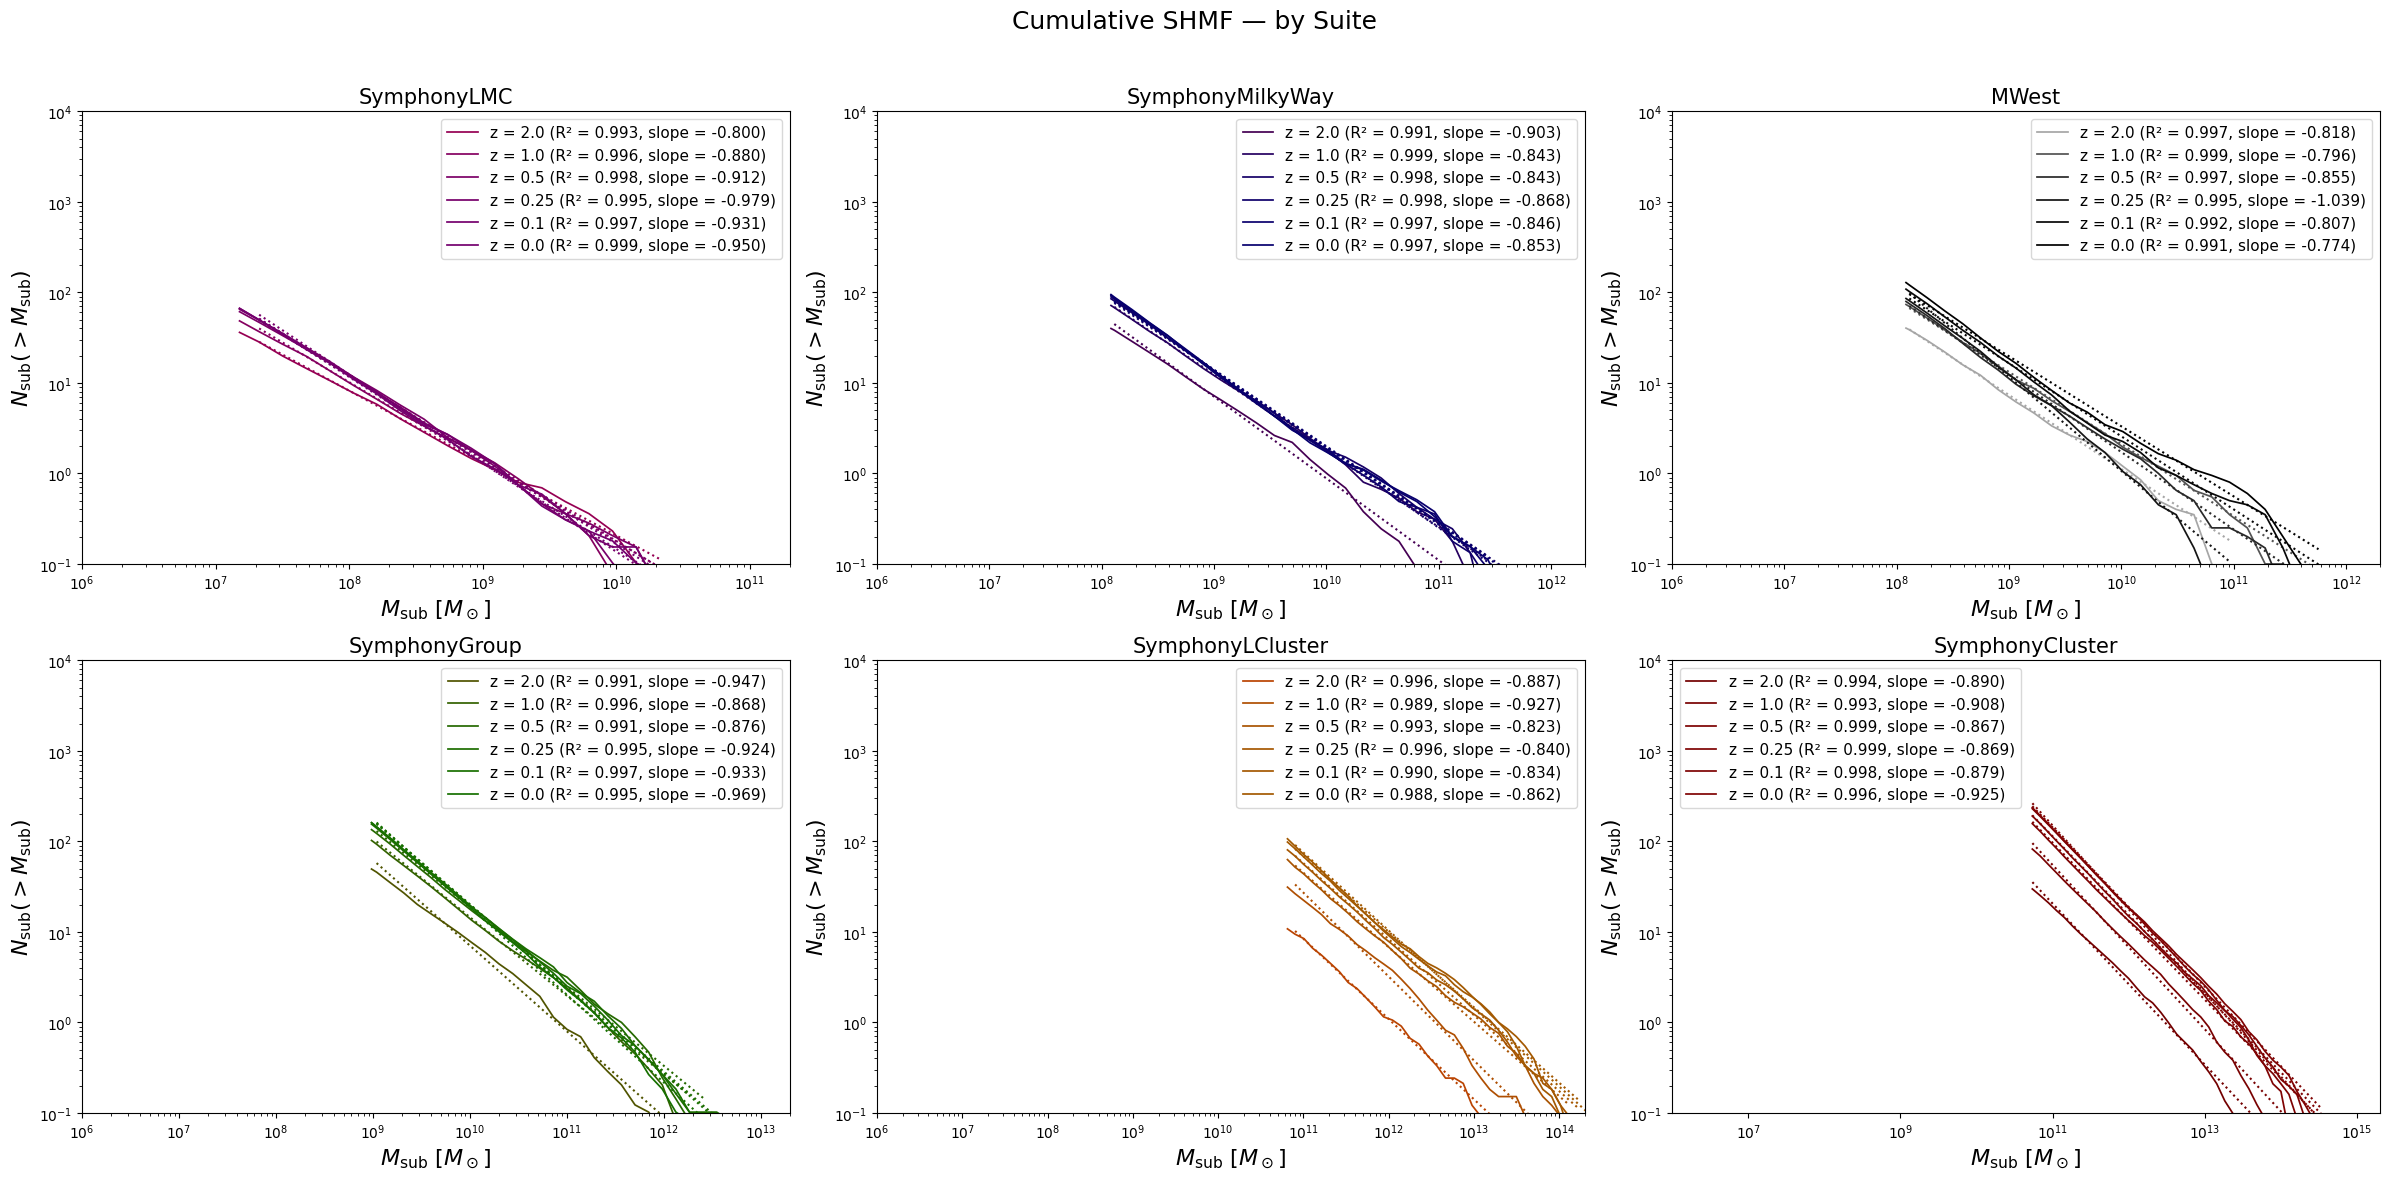

In [46]:
#TOGGLES:

## plot individual per-host lines
show_hosts_shmf = False

## plot 16-84% host-to-host scatter band
show_confidence_shmf = False

## plot linear fit to mean SHMF. True = on
## two points used for the linear fit:
## 1. bin corresponding to 300 particles
## 2. bin corresponding to where the mean SHMF crosses the 10^-1 point on the y-axis
show_shmf_fit = True

## if True, plot dN/d(log Msub) (differential SHMF)
## if False, plot N(>M) (cumulative SHMF)
show_differential = False

## if True, show the vertical line at 300 * mp (convergence)
convergence = False

## if True, the SHMF below 300 * mp is shown
show_dashed = False

## "suite" or "redshift" panel ordering
panel_by = "suite"


## ENTRYPOINT:
if panel_by == "suite":
    panel_list = suite_list
    panel_fn = plot_suite_panel
    title_type = "by Suite"
else:
    panel_list = redshifts_shmf
    panel_fn = plot_redshift_panel
    title_type = "by Redshift"

print(f"Starting SHMF plot — panel_by = '{panel_by}'")
print(f"Suites: {suite_list}")
print(f"Redshifts: {redshifts_shmf}")
print(f"Toggles — host lines: {show_hosts_shmf}, confidence band: {show_confidence_shmf}, "
      f"linear fit: {show_shmf_fit}, differential: {show_differential}, convergence: {convergence}\n")

n_panels = len(panel_list)
max_cols = 3                                 ## maximum # of panels per row
n_cols = min(n_panels, max_cols)
n_rows = int(np.ceil(n_panels / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize = (8 * n_cols, 6 * n_rows), squeeze = False)

## hide any unused axes in the last row
for idx in range(n_panels, n_rows * n_cols):
    axes[idx // n_cols, idx % n_cols].set_visible(False)

for p_idx, panel in enumerate(panel_list):
    ax = axes[p_idx // n_cols, p_idx % n_cols]
    panel_fn(ax, panel)

shmf_type = "Differential" if show_differential else "Cumulative"
fig.suptitle(f"{shmf_type} SHMF — {title_type}", fontsize = 18, y = 0.98)
plt.tight_layout(rect = [0, 0, 1, 0.96])
#fig.savefig("ordered by suite.png", dpi = 150, bbox_inches = "tight")
plt.show()

# N_subs(z) vs. Host_Mass(z)
* Looking at how the host mass accretion tracks with the # of subhalos as a function of "time" (redshift)

Loading suite SymphonyLMC... (39 hosts)
Host 39/39
Loaded 39/39 hosts (0 skipped)
RMSE_mass = 0.815530%, χ^2_mass = 0.323401
RMSE_nsubs = 2.170865%, χ^2_nsubs = 2.180653


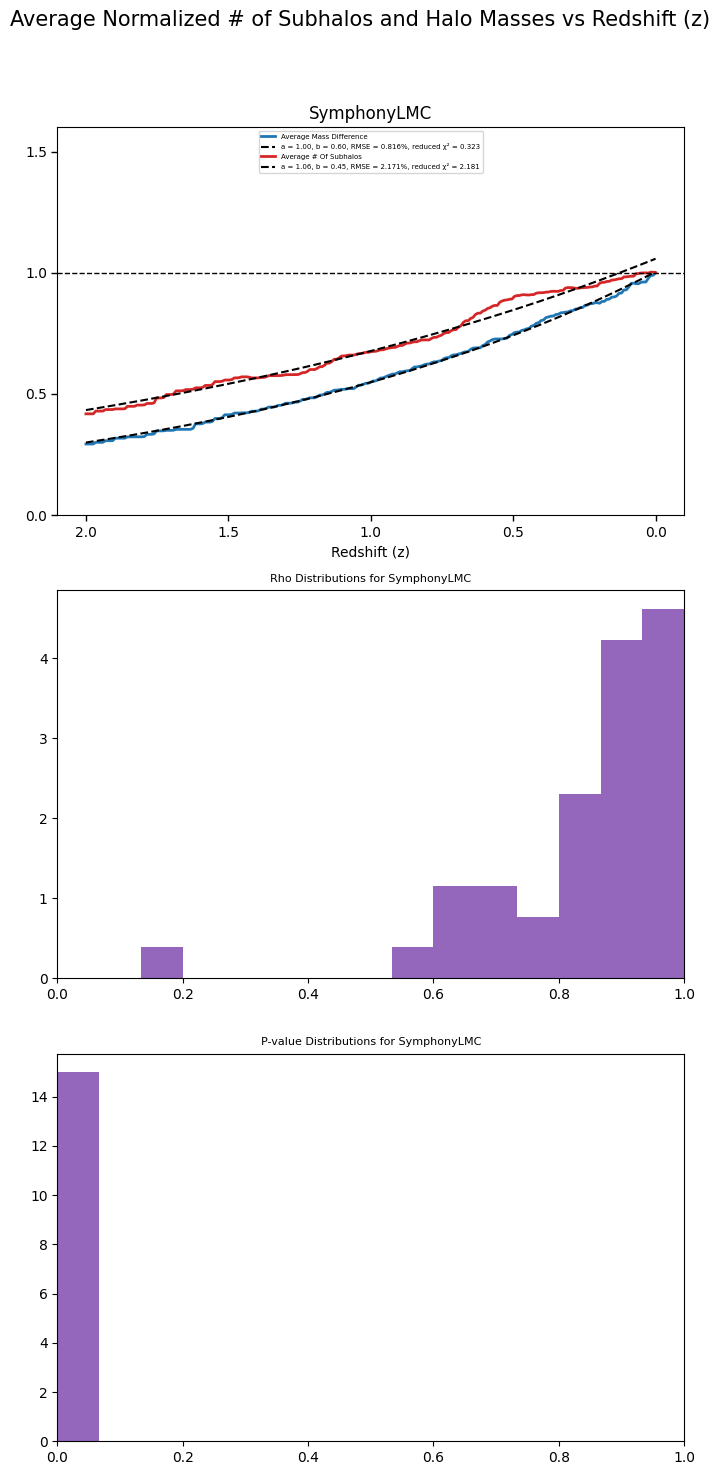

In [13]:
## defining the fitting functions from the Symphony paper
e = np.exp(1)

## FITTING FUNCTIONS:

## simple exponential decay model
def exponentialfit(x, a, b):
        return (a * e**(-1 * b * x))

## power-law + exponential correction (currently unused)
def linearcorrection(x, beta, gamma):
    return (((1 + x) ** beta) * (e ** (-1 * gamma * x)))

########################################################################################

## DATALOADER:

## useful maybe?
def get_mass_bins(suite_name, n_bins, m_max, min_particles):

    # get parameters for making histograms, as before:
    params = symlib.simulation_parameters(suite_name)
    m_min = params["mp"]/params["h100"] * min_particles
    bins = 10**np.linspace(np.log10(m_min), np.log10(m_max), n_bins + 1)
    left_bins = bins[:-1]

    return {"params": params,
            "m_min": m_min,
            "m_max": m_max,
            "bins": bins,
            "left_bins": left_bins,
            "h100": params["h100"]}

## reads the raw subhalo catalog for one host
def load_host(suite_name, i_host, base_dir):

    sim_dir = symlib.get_host_directory(base_dir, suite_name, i_host)
    scale_factors = symlib.scale_factors(sim_dir)
    h, hist = symlib.read_subhalos(sim_dir)

    return {"sim_dir": sim_dir,
            "scale_factors": scale_factors,
            "h": h,
            "hist": hist}


## given raw host data from load_host, compute (at each snapshot between z = 2 and z = 0):
## 1. host mass - total mass in subhalos within host rvir
## 2. number of subhalos within host rvir
## returns the raw (non-normalized) curves + the z = 0 values needed to normalize them later
def compute_host_curves(host_data):
    
    h = host_data["h"]
    scale_factors = host_data["scale_factors"]
    redshifts = np.linspace(2, 0, len(scale_factors))
    
    mass_diffs = np.zeros(len(scale_factors))
    num_subhalos = np.zeros(len(scale_factors))
    tot_subhalo_mass_at_z = 0.0

    for z_index, target_z in enumerate(redshifts):
        target_a = 1 / (1 + target_z)
        snap_index = np.argmin(np.abs(scale_factors - target_a))

        host_rvir = h["rvir"][0, snap_index]
        host_pos = h["x"][0, snap_index]
        host_mass = h["mvir"][0, snap_index]

        sub_rvir = h["rvir"][1:, snap_index]
        sub_pos = h["x"][1:, snap_index]
        sub_mass = h["mvir"][1:, snap_index]

        ok = h["ok"][1:, snap_index]
        ok_sub_pos = sub_pos[ok]
        ok_sub_rvir = sub_rvir[ok]
        ok_sub_mass = sub_mass[ok]

        ## distance from host center:
        dist = np.sqrt(np.sum((ok_sub_pos - host_pos) ** 2, axis = 1))
        inside_host_rvir = dist < (host_rvir - ok_sub_rvir)

        num_subhalos[z_index] = np.sum(inside_host_rvir)
        valid_sub_masses = np.where(inside_host_rvir, ok_sub_mass, 0.0)
        tot_subhalo_mass_at_z = np.sum(valid_sub_masses)
        mass_diffs[z_index] = host_mass - tot_subhalo_mass_at_z

    z0_mass_diff = h["mvir"][0][-1] - tot_subhalo_mass_at_z
    z0_num_nsubs = num_subhalos[-1]

    return {"redshifts": redshifts,
            "mass_diffs": mass_diffs,
            "num_subhalos": num_subhalos,
            "z0_mass_diff": z0_mass_diff,
            "z0_num_nsubs": z0_num_nsubs}

## loading all hosts:
def load_suite_hosts(suite_name, base_dir):
    n_hosts = symlib.n_hosts(suite_name)
    print(f"Loading suite {suite_name}... ({n_hosts} hosts)")

    host_curves = []
    skipped_hosts = []
    for i_host in range(n_hosts):
        print(f"Host {i_host + 1}/{n_hosts}", end = "\r", flush = True)

        try:
            host_data = load_host(suite_name, i_host, base_dir)
            host_curves.append(compute_host_curves(host_data))

        except Exception as e:
            print(f"\nSkipping host {i_host}: {e} in suite {suite_name}")
            skipped_hosts.append((suite_name, i_host))
    print(f"\nLoaded {len(host_curves)}/{n_hosts} hosts ({len(skipped_hosts)} skipped)")
    return host_curves, skipped_hosts
    
#############################################################################################

## STATISTICS:

## normalize one host's raw mass_diffs & num_subhalos to their z0 value, and compute the Spearman rank correlation between them
def normalize_host_curves(curves):

    norm_mass_diffs = curves["mass_diffs"] / curves["z0_mass_diff"]
    norm_num_nsubs = curves["num_subhalos"] / curves["z0_num_nsubs"]

    rho, p = scipy.stats.spearmanr(norm_mass_diffs / np.max(norm_mass_diffs), norm_num_nsubs / np.max(norm_num_nsubs))

    return {"redshifts": curves["redshifts"],
            "norm_mass_diffs": norm_mass_diffs,
            "norm_num_nsubs": norm_num_nsubs,
            "rho": rho,
            "p": p}

## computes R^2
#def r_squared(y_data, y_model):  
#    y_data = np.asarray(y_data)
#    y_model = np.asarray(y_model)
#    ss_res = np.sum((y_data - y_model) ** 2)
#    ss_tot = np.sum((y_data - np.mean(y_model)) ** 2)
#    return 1 - ss_res / ss_tot

## computes the root-mean-squared error (RMSE) between the suite-averaged curve and the exponential fit
def rmse(y_data, y_model):

    y_data = np.asarray(y_data)
    y_model = np.asarray(y_model)

    return np.sqrt(np.mean((y_data - y_model)**2))

## computes the reduced chi-squared (residuals normalized by per-bin uncertainty)
## sigma here is the standard error of the mean (SEM, the standard deviation across hosts divided by sqrt(n_hosts))
def reduced_chi_squared(y_data, y_model, sigma, n_params):

    y_data = np.asarray(y_data)
    y_model = np.asarray(y_model)
    sigma = np.asarray(sigma)

    valid = sigma > 0
    chi_sq = np.sum(((y_data[valid] - y_model[valid]) / sigma[valid])**2)
    dof = np.sum(valid) - n_params

    return chi_sq / dof

## given a list of raw per_host curves:
## - normalize each host
## - average across hosts
## - fit each averaged curve with an exponential model
def aggregate_suite(host_curves):
    
    normalized = [normalize_host_curves(c) for c in host_curves]

    ## MWest and EDEN have different snapshot counts compared to Symphony suites
    ## interpolating onto a common gridspace (from z = 2 to z = 0, 235 snapshots)
    common_redshifts = np.linspace(2, 0, 235)

    def interp_host(n):
        return {"norm_mass_diffs": np.interp(common_redshifts, n["redshifts"][::-1], n["norm_mass_diffs"][::-1]),
                "norm_num_nsubs":  np.interp(common_redshifts, n["redshifts"][::-1], n["norm_num_nsubs"][::-1])}

    resampled = [interp_host(n) for n in normalized]

    redshifts = common_redshifts
    norm_mass_diffs = np.array([r["norm_mass_diffs"] for r in resampled])
    norm_num_nsubs  = np.array([r["norm_num_nsubs"]  for r in resampled])
 
    avg_norm_mass_diffs = np.mean(norm_mass_diffs, axis = 0)
    avg_norm_num_nsubs = np.mean(norm_num_nsubs, axis = 0)
    std_norm_mass_diffs = np.std(norm_mass_diffs, axis = 0)
    std_norm_num_nsubs = np.std(norm_num_nsubs, axis = 0)
 
    fit_mass, _ = curve_fit(exponentialfit, redshifts, avg_norm_mass_diffs)
    fit_nsubs, _ = curve_fit(exponentialfit, redshifts, avg_norm_num_nsubs)

    n_hosts = len(host_curves)
    sigma_mass = std_norm_mass_diffs / np.sqrt(n_hosts)
    sigma_nsubs = std_norm_num_nsubs / np.sqrt(n_hosts)
    
    rmse_mass = rmse(avg_norm_mass_diffs, exponentialfit(redshifts, *fit_mass))
    rmse_nsubs = rmse(avg_norm_num_nsubs, exponentialfit(redshifts, *fit_nsubs))
    
    reduced_chisq_mass  = reduced_chi_squared(avg_norm_mass_diffs,  exponentialfit(redshifts, *fit_mass),  sigma_mass,  n_params = 2)
    reduced_chisq_nsubs = reduced_chi_squared(avg_norm_num_nsubs, exponentialfit(redshifts, *fit_nsubs), sigma_nsubs, n_params = 2)

    print(f"RMSE_mass = {(rmse_mass * 100):2f}%, χ^2_mass = {(reduced_chisq_mass):2f}")
    print(f"RMSE_nsubs = {(rmse_nsubs * 100):2f}%, χ^2_nsubs = {(reduced_chisq_nsubs):2f}")
 
    return {"redshifts": redshifts,
            "avg_norm_mass_diffs": avg_norm_mass_diffs,
            "avg_norm_num_nsubs": avg_norm_num_nsubs,
            "std_norm_mass_diffs": std_norm_mass_diffs,
            "std_norm_num_nsubs": std_norm_num_nsubs,
            "fit_mass": fit_mass,
            "fit_nsubs": fit_nsubs,
            "rmse_mass": rmse_mass,
            "rmse_nsubs": rmse_nsubs,
            "reduced_chisq_mass": reduced_chisq_mass,
            "reduced_chisq_nsubs": reduced_chisq_nsubs,
            "rho_suite": [n["rho"] for n in normalized],
            "p_suite": [n["p"] for n in normalized]}

##################################################################################################################################

## PLOTTER:

## fill in one column of the 3-row figure (curves, rho hist, p hist for a single suite)
def plot_suite(axs, suite_index, suite_name, suite_result, colors):

    redshifts = suite_result["redshifts"]
    color = colors[suite_name]

    ax = axs[0, suite_index]
    ax.plot(redshifts, suite_result["avg_norm_mass_diffs"], color = "tab:blue", lw = 2, label = "Average Mass Difference")
    #ax.fill_between(redshifts, suite_result["avg_norm_mass_diffs"] + suite_result["std_norm_mass_diffs"],
    #                suite_result["avg_norm_mass_diffs"] - suite_result["std_norm_mass_diffs"], color = "lightcyan")
    ax.plot(redshifts, exponentialfit(redshifts, *suite_result["fit_mass"]), color = "black", linestyle = "--",
            label = f"a = {suite_result['fit_mass'][0]:.2f}, b = {suite_result['fit_mass'][1]:.2f}, "
                    f"RMSE = {(suite_result['rmse_mass']*100):.3f}%, reduced \u03C7\u00b2 = {suite_result['reduced_chisq_mass']:.3f}")

    ax.plot(redshifts, suite_result["avg_norm_num_nsubs"], color = "tab:red", lw = 2,
            label = "Average # Of Subhalos")
    #ax.fill_between(redshifts, suite_result["avg_norm_num_nsubs"] + suite_result["std_norm_num_nsubs"],
    #                suite_result["avg_norm_num_nsubs"] - suite_result["std_norm_num_nsubs"], color = "mistyrose")
    ax.plot(redshifts, exponentialfit(redshifts, *suite_result["fit_nsubs"]), color = "black", linestyle = "--",
            label = f"a = {suite_result['fit_nsubs'][0]:.2f}, b = {suite_result['fit_nsubs'][1]:.2f}, "
                    f"RMSE = {(suite_result['rmse_nsubs']*100):.3f}%, reduced \u03C7\u00b2 = {suite_result['reduced_chisq_nsubs']:.3f}")

    ax.invert_xaxis()
    ax.set_xlabel("Redshift (z)")
    ax.set_ylim(0.0, 1.6)
    ax.axhline(y = 1, color = "black", lw = 1, linestyle = "--")
    ax.locator_params(axis = "x", nbins = 5)
    ax.locator_params(axis = "y", nbins = 5)
    ax.tick_params(axis = "both", which = "major", length = 4, width = 1, direction = "out")
    ax.legend(fontsize = 5, loc = "upper center")
    ax.set_title(suite_name)

    ax_rho = axs[1, suite_index]
    ax_rho.hist(suite_result["rho_suite"], bins = 15, range = (0, 1), color = color, density = True)
    ax_rho.set_xlim(0, 1)
    ax_rho.set_title(f"Rho Distributions for {suite_name}", fontsize = 8)

    ax_p = axs[2, suite_index]
    ax_p.hist(suite_result["p_suite"], bins = 15, range = (0, 1), color = color, density = True)
    ax_p.set_xlim(0, 1)
    ax_p.set_title(f"P-value Distributions for {suite_name}", fontsize = 8)


## plotting all suites:
def plot_all_suites(suite_results, colors):

    suite_names = list(suite_results.keys())
    ncols = len(suite_names)
    nrows = 3
    fig, axs = plt.subplots(ncols = ncols, nrows = nrows, figsize = (7 * ncols, 5 * nrows), squeeze = False)

    for suite_index, suite_name in enumerate(suite_names):
        plot_suite(axs, suite_index, suite_name, suite_results[suite_name], colors)
        
    fig.suptitle("Average Normalized # of Subhalos and Halo Masses vs Redshift (z)", fontsize = 15)
    fig.tight_layout(rect = [0, 0, 1, 0.95])  ## leaves room for suptitle at the top
    #fig.savefig("Nsubs vs. Host Masses [all suites!!] (RMSE + reduced χ^2).png", bbox_inches = "tight")
    plt.show()

    return fig, axs

#######################################################################################################################

## ENTRYPOINT:

def run_all_suites(suite_list, base_dir, colors):
    suite_results = {}
    all_skipped = []
    for suite_name in suite_list:
        host_curves, skipped_hosts = load_suite_hosts(suite_name, base_dir)
        all_skipped.extend(skipped_hosts)
        suite_results[suite_name] = aggregate_suite(host_curves)

    if all_skipped:
        print(f"\nSkipped hosts across all suites:")
        for suite_name, i_host in all_skipped:
            print(f"{suite_name}, host {i_host}")
 
    fig, axs = plot_all_suites(suite_results, colors)
    return fig, axs, suite_results, all_skipped
 
 
if __name__ == "__main__":
    fig, axs, suite_results, all_skipped = run_all_suites(suite_list, base_dir, colors)


# look at p-values and try to resolve the question regarding the delta-function-like behavior --> probably unphysical??
# upgrade the distance calculation and factor in the possibility of there being subhalos that are partially inside the host halo, especially at high redshift

Nsubs(z)/Nsubs(z=0) vs. Host Mass(z)/Host Mass(z=0):
* Individual hosts as a faint line, mean as a bold line (colored by suite) --> add 16-84% confidence as well maybe
* Time series of points starting at (0, 0) and ending at (1, 1)
* Perfect correlation would traverse along the 1-to-1 line

Goal: assess how well MAH predicts Nsub on an individual host and an average basis

Loading suite SymphonyLMC... (39 hosts)
Host 39/39
Loaded 39/39 hosts (0 skipped)
Loading suite SymphonyMilkyWay... (45 hosts)
Host 45/45
Loaded 45/45 hosts (0 skipped)
Loading suite MWest... (20 hosts)
Host 20/20
Loaded 20/20 hosts (0 skipped)
Loading suite SymphonyGroup... (49 hosts)
Host 49/49
Loaded 49/49 hosts (0 skipped)
Loading suite SymphonyLCluster... (33 hosts)
Host 33/33
Loaded 33/33 hosts (0 skipped)
Loading suite SymphonyCluster... (81 hosts)
Host 81/81
Loaded 81/81 hosts (0 skipped)


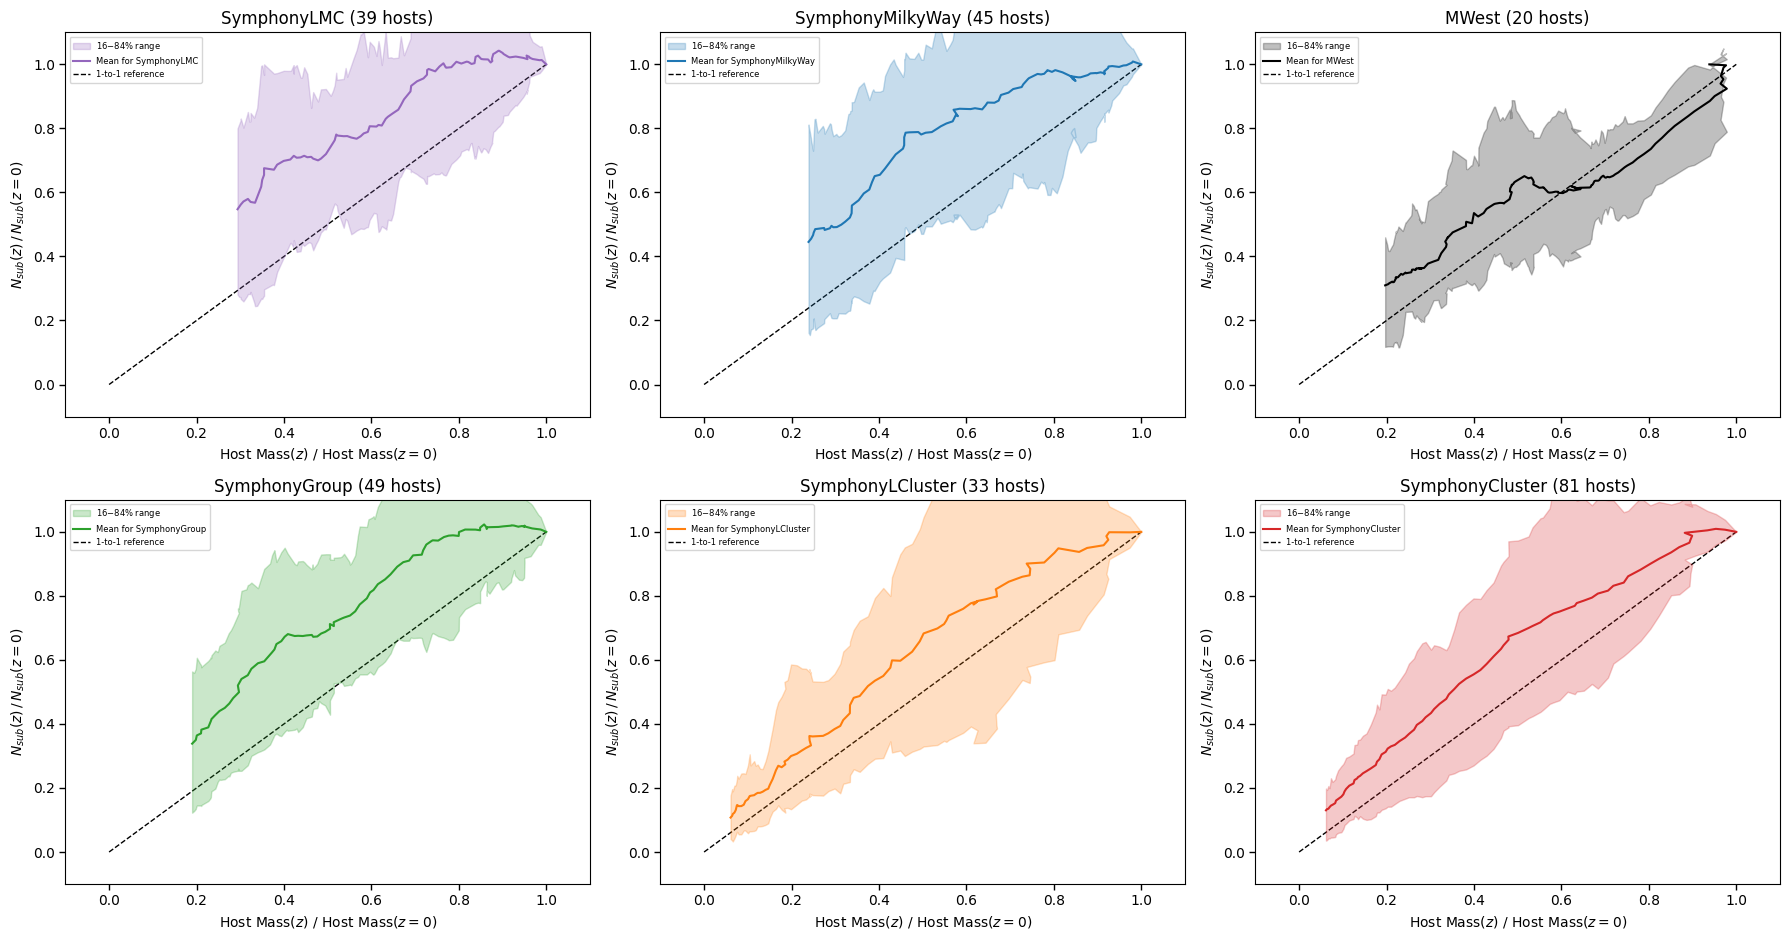

In [37]:
## DATALOADER:

def get_mass_bins(suite_name, n_bins, m_max, min_particles):

    # get parameters for making histograms, as before:
    params = symlib.simulation_parameters(suite_name)
    m_min = params["mp"]/params["h100"] * min_particles
    bins = 10**np.linspace(np.log10(m_min), np.log10(m_max), n_bins + 1)
    left_bins = bins[:-1]

    return {"params": params,
            "m_min": m_min,
            "m_max": m_max,
            "bins": bins,
            "left_bins": left_bins,
            "h100": params["h100"]}


def load_host(suite_name, i_host, base_dir):

    sim_dir = symlib.get_host_directory(base_dir, suite_name, i_host)
    scale_factors = symlib.scale_factors(sim_dir)
    h, hist = symlib.read_subhalos(sim_dir)

    return {"sim_dir": sim_dir,
            "suite_name": suite_name,
            "scale_factors": scale_factors,
            "h": h,
            "hist": hist}


def compute_host_curves(host_data, min_particles = 300):
    
    h = host_data["h"]
    scale_factors = host_data["scale_factors"]
    redshifts = np.linspace(2, 0, len(scale_factors))

    params = symlib.simulation_parameters(host_data["suite_name"])
    resolution_cut = params["mp"] / params["h100"] * min_particles
    
    mass_diffs = np.zeros(len(scale_factors))
    num_subhalos = np.zeros(len(scale_factors))
    tot_subhalo_mass_at_z = 0.0

    for z_index, target_z in enumerate(redshifts):
        
        target_a = 1 / (1 + target_z)
        snap_index = np.argmin(np.abs(scale_factors - target_a))

        host_rvir = h["rvir"][0, snap_index]
        host_pos = h["x"][0, snap_index]
        host_mass = h["mvir"][0, snap_index]

        sub_rvir = h["rvir"][1:, snap_index]
        sub_pos = h["x"][1:, snap_index]
        sub_mass = h["mvir"][1:, snap_index]

        ok = h["ok"][1:, snap_index]
        above_res_limit = sub_mass >= resolution_cut

        ## applying both the ok cut and the 300 particles cut
        valid = ok & above_res_limit
        
        ok_sub_pos = sub_pos[valid]
        ok_sub_rvir = sub_rvir[valid]
        ok_sub_mass = sub_mass[valid]

        ## distance from host center:
        dist = np.sqrt(np.sum((ok_sub_pos - host_pos) ** 2, axis = 1))
        inside_host_rvir = dist < (host_rvir - ok_sub_rvir)

        num_subhalos[z_index] = np.sum(inside_host_rvir)
        valid_sub_masses = np.where(inside_host_rvir, ok_sub_mass, 0.0)
        tot_subhalo_mass_at_z = np.sum(valid_sub_masses)
        mass_diffs[z_index] = host_mass - tot_subhalo_mass_at_z

    z0_mass_diff = h["mvir"][0][-1] - tot_subhalo_mass_at_z
    z0_num_nsubs = num_subhalos[-1]

    return {"redshifts": redshifts,
            "mass_diffs": mass_diffs,
            "num_subhalos": num_subhalos,
            "z0_mass_diff": z0_mass_diff,
            "z0_num_nsubs": z0_num_nsubs}

## loading all hosts:
def load_suite_hosts(suite_name, base_dir):
    n_hosts = symlib.n_hosts(suite_name)
    print(f"Loading suite {suite_name}... ({n_hosts} hosts)")

    host_curves = []
    skipped_hosts = []
    for i_host in range(n_hosts):
        print(f"Host {i_host + 1}/{n_hosts}", end = "\r", flush = True)

        try:
            host_data = load_host(suite_name, i_host, base_dir)
            host_curves.append(compute_host_curves(host_data))

        except Exception as e:
            print(f"\nSkipping host {i_host}: {e} in suite {suite_name}")
            skipped_hosts.append((suite_name, i_host))
    print(f"\nLoaded {len(host_curves)}/{n_hosts} hosts ({len(skipped_hosts)} skipped)")
    return host_curves, skipped_hosts
    
#############################################################################################

## STATISTICS:

## normalize one host's raw mass_diffs & num_subhalos to their z0 value, and compute the Spearman rank correlation between them
def normalize_host_curves(curves):

    norm_mass_diffs = curves["mass_diffs"] / curves["z0_mass_diff"]
    norm_num_nsubs = curves["num_subhalos"] / curves["z0_num_nsubs"]

    rho, p = scipy.stats.spearmanr(norm_mass_diffs / np.max(norm_mass_diffs), norm_num_nsubs / np.max(norm_num_nsubs))

    return {"redshifts": curves["redshifts"],
            "norm_mass_diffs": norm_mass_diffs,
            "norm_num_nsubs": norm_num_nsubs,
            "rho": rho,
            "p": p}


## interpolate one (already normalized) host's curves onto a common redshift grid
def resample_host_to_grid(normalized_curves, common_redshifts):
    return {"norm_mass_diffs": np.interp(common_redshifts, normalized_curves["redshifts"][::-1],
                                          normalized_curves["norm_mass_diffs"][::-1]),
            "norm_num_nsubs":  np.interp(common_redshifts, normalized_curves["redshifts"][::-1],
                                          normalized_curves["norm_num_nsubs"][::-1])}


def aggregate_suite_trajectory(host_curves, n_grid = 200):

    ## MWest and EDEN have different snapshot counts compared to Symphony suites
    ## interpolating onto a common gridspace (from z = 2 to z = 0, n_grid = number of snapshots)
    common_redshifts = np.linspace(2, 0, n_grid)

    normalized = [normalize_host_curves(c) for c in host_curves]
    resampled = [resample_host_to_grid(n, common_redshifts) for n in normalized]

    mass_matrix = np.array([r["norm_mass_diffs"] for r in resampled])
    nsubs_matrix = np.array([r["norm_num_nsubs"] for r in resampled])

    mean_mass = np.mean(mass_matrix, axis = 0)
    mean_nsubs = np.mean(nsubs_matrix, axis = 0)

    p16_nsubs, p84_nsubs = np.percentile(nsubs_matrix, [16, 84], axis = 0)
 
    return {"redshifts": common_redshifts,
            "mass_matrix": mass_matrix,
            "nsubs_matrix": nsubs_matrix,
            "mean_mass": mean_mass,
            "mean_nsubs": mean_nsubs,
            "p16_nsubs": p16_nsubs,
            "p84_nsubs": p84_nsubs,
            "n_hosts": len(host_curves)}

##################################################################################################################################

## PLOTTER:

## fill in one panel: Nsubs(z)/Nsubs(z=0) vs Mass(z)/Mass(z=0) for a single suite
def plot_suite_trajectory(ax, suite_name, suite_result, colors):

    color = colors[suite_name]
    mass_matrix = suite_result["mass_matrix"]
    nsubs_matrix = suite_result["nsubs_matrix"]

    ## faint individual host traces
    #for i in range(suite_result["n_hosts"]):
    #    ax.plot(mass_matrix[i], nsubs_matrix[i], color = color, alpha = 0.15, lw = 0.75, zorder = 1)

    ## 16-84% envelope on Nsubs
    ax.fill_between(suite_result["mean_mass"], suite_result["p16_nsubs"], suite_result["p84_nsubs"],
                    color = color, alpha = 0.25, zorder = 2, label = "16$-$84% range")

    ## mean trajectory, solid/bold
    ax.plot(suite_result["mean_mass"], suite_result["mean_nsubs"], color = color, lw = 1.5, zorder = 3, label = f"Mean for {suite_name}")

    ## 1-to-1 reference line
    ax.plot([0, 1], [0, 1], color = "black", linestyle = "--", lw = 1, zorder = 0, label = "1-to-1 reference")
    
    ax.set_xlabel(r"Host Mass($z$) / Host Mass($z=0$)")
    ax.set_ylabel(r"$N_{sub}(z)\,/\,N_{sub}(z=0)$")
    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(-0.1, 1.1)
    ax.set_title(f"{suite_name} ({suite_result['n_hosts']} hosts)")
    ax.legend(fontsize = 6, loc = "upper left")
    ax.tick_params(axis = "both", which = "major", length = 4, width = 1, direction = "out")


## plotting all suites:
def plot_all_suites_trajectories(suite_results, colors, max_cols = 3):

    suite_names = list(suite_results.keys())
    n_suites = len(suite_names)
    ncols = min(max_cols, n_suites)
    nrows = int(np.ceil(n_suites / ncols))
    
    fig, axs = plt.subplots(ncols = ncols, nrows = nrows, figsize = (6 * ncols, 5 * nrows), squeeze = False)
    flat_axs = axs.flatten()

    for i, suite_name in enumerate(suite_names):
        plot_suite_trajectory(flat_axs[i], suite_name, suite_results[suite_name], colors)

    ## delete any unused axes
    for j in range(n_suites, len(flat_axs)):
        fig.delaxes(flat_axs[j])
        
    #fig.suptitle(r"$N_{sub}$ vs. Host Mass Growth Trajectories (normalized to $z=0$)", fontsize = 15)
    fig.tight_layout(rect = [0, 0, 1, 0.95])
    fig.savefig("Nsub(z) over Nsub(z=0) vs Host Mass(z) over Host Mass(z=0) [hosts hidden].png", dpi = 300, bbox_inches = "tight")
    plt.show()

    return fig, axs

#######################################################################################################################

## ENTRYPOINT:

def run_all_suites(suite_list, base_dir, colors):
    
    suite_results = {}
    all_skipped = []
    
    for suite_name in suite_list:
        host_curves, skipped_hosts = load_suite_hosts(suite_name, base_dir)
        all_skipped.extend(skipped_hosts)
        suite_results[suite_name] = aggregate_suite_trajectory(host_curves)

    if all_skipped:
        print(f"\nSkipped hosts across all suites:")
        for suite_name, i_host in all_skipped:
            print(f"{suite_name}, host {i_host}")
 
    fig, axs = plot_all_suites_trajectories(suite_results, colors)
    return fig, axs, suite_results, all_skipped
 
 
if __name__ == "__main__":
    fig, axs, suite_results, all_skipped = run_all_suites(suite_list, base_dir, colors)

Another interesting question is "what fraction of the host's mass is made of the "smooth" background particles being accreted onto the host versus "bursty" particles being accreted when subhalos fall in?"

The expectation is that because dark matter halos are supported against gravitational collapse by the random motions of the particles, all of the halos (including the host) should be made of mostly "smooth" particles, with only a small number of the particles being "bursty" or "clumpy." The host is so large and massive that it can "afford" to have some inhomogeneities in it, but the subhalos are all "smooth" on the inside.

The infalling particles are a different fraction of "smooth" versus "clumpy," possibly closer to 50-50? However, due to tidal stripping, the "clumpy" particles that belong to a particular subhalo become "smooth" as they get stripped away.

First, let's look at only the particles belonging to the main host (labeled as being part of the host by the halo finder, and also inside the host virial radius at a given time), and let's look at the fraction of the host mass that is also contained in subhalos. We will assume that the remaining mass is all "smooth" particles that aren't part of any substructure.

In [45]:
from astropy.cosmology import FlatLambdaCDM

Starting on suite SymphonyLMC...
Starting on suite SymphonyMilkyWay...
Current host: 1/45

C:\Users\steph\AppData\Local\Temp\ipykernel_4016\2480898267.py:102: RuntimeWarning: Mean of empty slice
  mean_clumpy = np.nanmean(all_clumpy, axis = 0)
C:\Users\steph\AppData\Local\Temp\ipykernel_4016\2480898267.py:106: RuntimeWarning: Mean of empty slice
  mean_smooth = np.nanmean(all_smooth, axis = 0)


Starting on suite MWest...
Starting on suite SymphonyGroup...
Starting on suite SymphonyLCluster...
Starting on suite SymphonyCluster...
Current host: 81/81

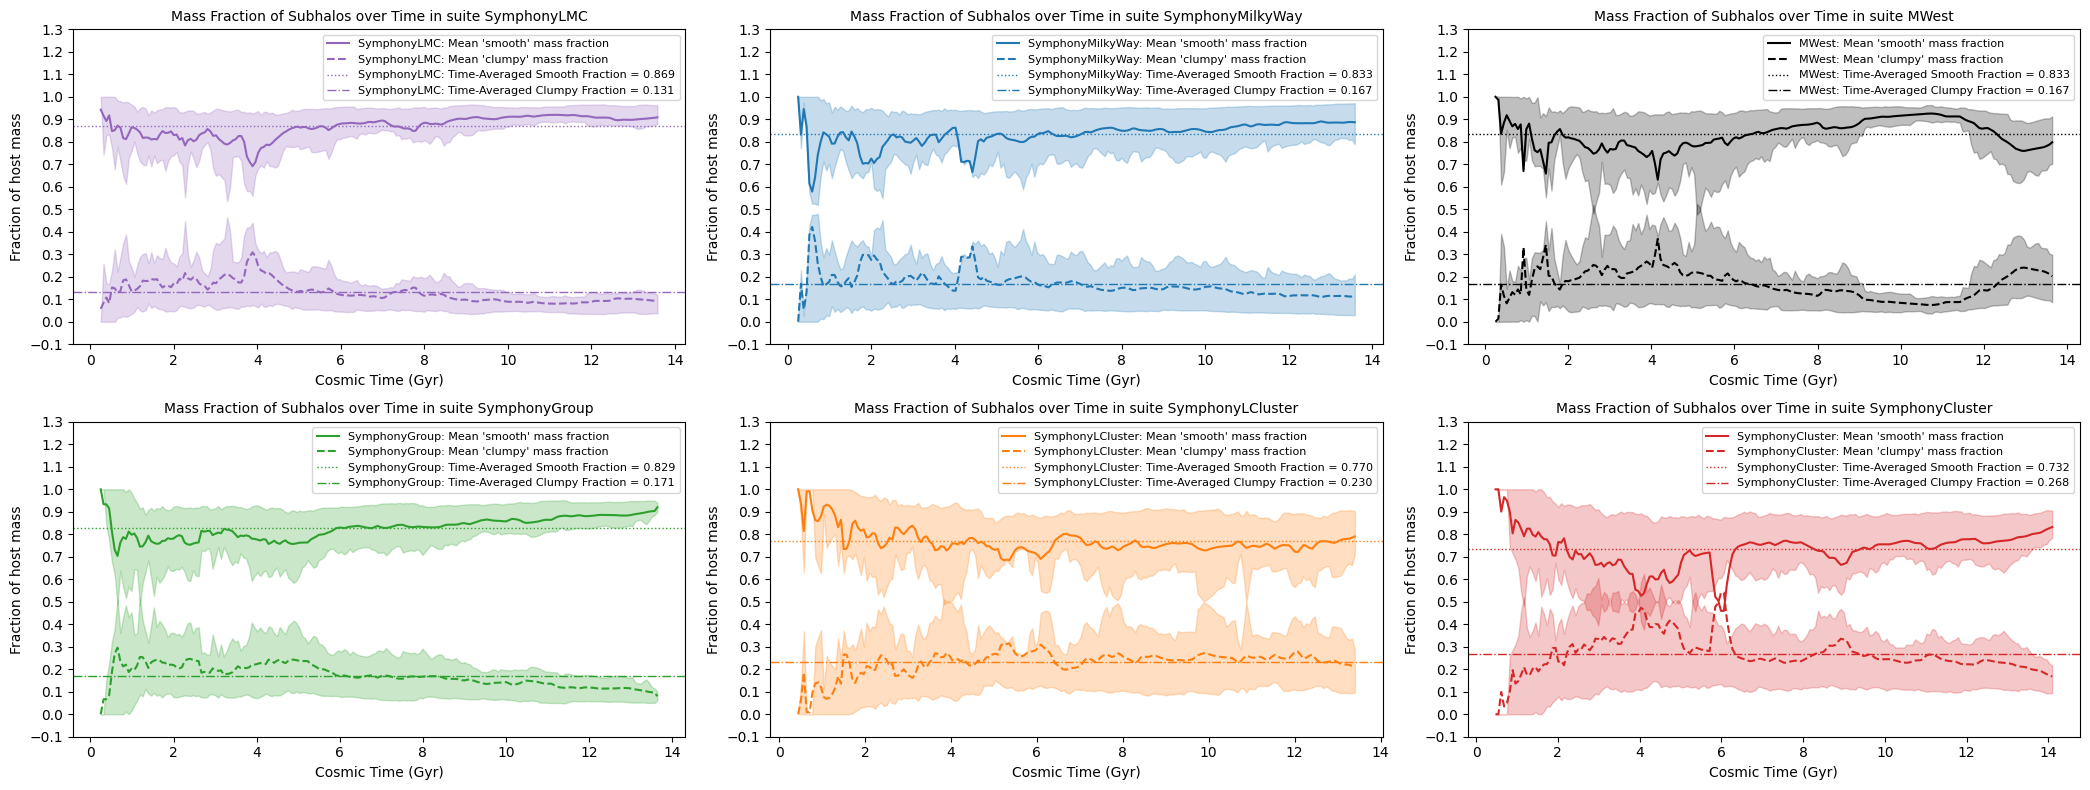

In [54]:
n_suites = len(suite_list)
ncols = 3 if n_suites > 1 else 1
nrows = int(np.ceil(n_suites / ncols))

n_grid = 200  # number of points in the common cosmic-time grid

fig, axes = plt.subplots(nrows, ncols, figsize = (7 * ncols, 4 * nrows), squeeze = False)
axes_flat = axes.flatten()

for suite_index, suite_name in enumerate(suite_list):
    ax = axes_flat[suite_index]

    print(f"Starting on suite {suite_name}...")

    n_hosts = symlib.n_hosts(suite_name)

    all_clumpy = []
    all_smooth = []

    common_time_grid = None
    cosmo = None

    for i_host in range(n_hosts):

        print(f"Current host: {i_host + 1}/{n_hosts}", end = "\r", flush = True)

        sim_dir = symlib.get_host_directory(base_dir, suite_name, i_host)
        scale_factors = symlib.scale_factors(sim_dir)
        snapshots = np.arange(0, len(scale_factors), 1)
        params = symlib.simulation_parameters(sim_dir)

        mp = params["mp"] / params["h100"]
        particle_cut = 300 * mp

        h, hist = symlib.read_subhalos(sim_dir)

        ## 300 particles and "ok" cut for the host and subhalos:
        ok = h["ok"]
        mvir = h["mvir"]

        host_ok = ok[0, :]
        host_mass_all_snaps = mvir[0, :]

        sub_ok = ok[1:, :]
        sub_mass = mvir[1:, :]

        ## position cut for subhalos:
        host_x = h["x"][0, :]
        sub_x = h["x"][1:, :]
        host_rvir = h["rvir"][0, :]

        r = np.sqrt(np.sum(sub_x**2, axis = -1))
        inside_rvir = r <= host_rvir

        mass_cut = sub_mass >= particle_cut
        valid = sub_ok & inside_rvir & mass_cut
        masked_sub_mass = np.where(valid, sub_mass, 0.0)

        ## total mass of subhalos that meet these criteria (on a per-snapshot basis):
        sub_mass_all_snaps = np.sum(masked_sub_mass, axis = 0)
        
        ## apply the "ok" cut and the 300-particle cut to the host:
        host_mass_cut = host_mass_all_snaps >= particle_cut
        valid_host = host_ok & host_mass_cut & (host_mass_all_snaps > 0)

        ## explicit clumpy and smooth fractions
        clumpy_frac = np.full_like(host_mass_all_snaps, np.nan, dtype = float)
        clumpy_frac[valid_host] = sub_mass_all_snaps[valid_host] / host_mass_all_snaps[valid_host]
        
        smooth_frac = np.full_like(host_mass_all_snaps, np.nan, dtype = float)
        smooth_frac[valid_host] = 1.0 - clumpy_frac[valid_host]

        ## convert this host's own scale factors to cosmic time
        if cosmo is None:
            cosmo = FlatLambdaCDM(H0 = params["h100"] * 100, Om0 = params["Om0"])
            ## build the common 200-point cosmic-time grid once per suite,
            ## spanning from z_max down to z = 0 using this suite's cosmology
            t_min = cosmo.age(z_max).value
            t_max = cosmo.age(0.0).value
            common_time_grid = np.linspace(t_min, t_max, n_grid)

        redshift_host = 1.0 / scale_factors - 1.0
        cosmic_time_host = cosmo.age(redshift_host).value  # Gyr, monotonically increasing

        ## interpolate this host's fractions onto the common grid.
        ## only interpolate over the host's valid (non-NaN) points; anything outside that valid time range is left as NaN (not extrapolated).
        valid_idx = ~np.isnan(clumpy_frac)
        if valid_idx.sum() < 2:
            # not enough valid points to interpolate this host at all — skip it
            continue

        interp_clumpy = np.interp(common_time_grid, cosmic_time_host[valid_idx], clumpy_frac[valid_idx], left = np.nan, right = np.nan)
        interp_smooth = np.interp(common_time_grid, cosmic_time_host[valid_idx], smooth_frac[valid_idx], left = np.nan, right = np.nan)
        
        all_clumpy.append(interp_clumpy)
        all_smooth.append(interp_smooth)

    ## stack into (n_hosts, n_snaps) arrays and average over hosts, ignoring NaNs
    all_clumpy = np.vstack(all_clumpy)
    all_smooth = np.vstack(all_smooth)

    mean_clumpy = np.nanmean(all_clumpy, axis = 0)
    p16_clumpy = np.nanpercentile(all_clumpy, 16, axis = 0)
    p84_clumpy = np.nanpercentile(all_clumpy, 84, axis = 0)
    
    mean_smooth = np.nanmean(all_smooth, axis = 0)
    p16_smooth = np.nanpercentile(all_smooth, 16, axis = 0)
    p84_smooth = np.nanpercentile(all_smooth, 84, axis = 0)

    ax.plot(common_time_grid, mean_smooth, color = colors[suite_name], lw = 1.5, label = f"{suite_name}: Mean 'smooth' mass fraction ")
    ax.fill_between(common_time_grid, p16_smooth, p84_smooth, color = colors[suite_name], alpha = 0.25)

    ax.plot(common_time_grid, mean_clumpy, color = colors[suite_name], lw = 1.5, linestyle = "--", label = f"{suite_name}: Mean 'clumpy' mass fraction")
    ax.fill_between(common_time_grid, p16_clumpy, p84_clumpy, color = colors[suite_name], alpha = 0.25)

    ## plotting horizontal lines for the time-averaged fractions over all snapshots (ignoring NaNs)
    time_avg_smooth = np.nanmean(mean_smooth)
    time_avg_clumpy = np.nanmean(mean_clumpy)

    ax.axhline(time_avg_smooth, color = colors[suite_name], lw = 1.0, linestyle = ":",
               label = f"{suite_name}: Time-Averaged Smooth Fraction = {time_avg_smooth:.3f}")
    ax.axhline(time_avg_clumpy, color = colors[suite_name], lw = 1.0, linestyle = "-.",
               label = f"{suite_name}: Time-Averaged Clumpy Fraction = {time_avg_clumpy:.3f}")

    ax.set_xlabel("Cosmic Time (Gyr)")
    ax.set_ylabel("Fraction of host mass")
    ax.set_ylim(-0.1, 1.3)
    ax.yaxis.set_major_locator(plt.MultipleLocator(0.1))
    ax.set_title(f"Mass Fraction of Subhalos over Time in suite {suite_name}", fontsize = 10)
    ax.legend(loc = "best", fontsize = 8)

## remove any unused axes (when n_suites doesn't evenly fill the grid)
for j in range(n_suites, len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.tight_layout()
plt.savefig("test.png")
plt.show()

0 0
All Objects Populated!



KeyboardInterrupt



Error in callback <function _draw_all_if_interactive at 0x000001FD8DD4FB50> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

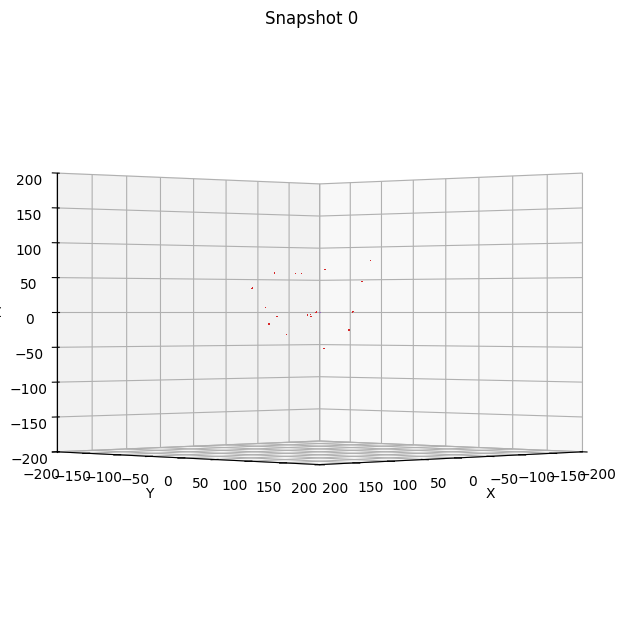

In [4]:
## GOAL: create a visualization that shows the behavior of subhalos in MWest over all snapshots
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.animation as animation

base_dir = "C:/Users/steph/Symphony"
suite_list = ["MWest"]

image_directory = "mwest_visual/*.png"   # where to look for images to turn into a GIF, and where to save the GIF
output_directory = "mwest_visual"
output_gif_path = "mwest_visual.gif"

## create a 3-D plot that we can rotate and manipulate later to see what's going on
fig = plt.figure(figsize = (7.5, 7.5))
ax = fig.add_subplot(111, projection = '3d')

u = np.linspace(0, 2 * np.pi, 40)   # defining these rotation linspaces for later
v = np.linspace(0, np.pi, 20)

sphere_x = np.outer(np.cos(u), np.sin(v))
sphere_y = np.outer(np.sin(u), np.sin(v))
sphere_z = np.outer(np.ones_like(u), np.cos(v))

## now we need to read the location and virial radius data for every subhalo and plot it
for suite_index, suite in enumerate(suite_list):
    n_hosts = symlib.n_hosts(suite)

    host = "Halo113"

    sim_dir = symlib.get_host_directory(base_dir, suite, host)
    scale_factors = symlib.scale_factors(sim_dir)
    scale_factors = scale_factors[scale_factors <= 1]

    snapshots = np.arange(0, 240, 5)
        
    h, hist = symlib.read_subhalos(sim_dir)

    for snap_index, snap in enumerate(snapshots):
        print(snap_index, snap)
        
        filename = f"Snapshot {(snap):.2f}.png"
        full_path = os.path.join(output_directory, filename)

        host_rvir = h["rvir"][0, snap]
        host_mvir = h["mvir"][0, snap]
        host_pos = h["x"][0, snap]

        sub_rvir = h["rvir"][1:, snap]
        sub_pos = h["x"][1:, snap]
        
        ok1 = h["ok"][1:, snap]
        ok_sub_pos = sub_pos[ok1]
        ok_sub_rvir = sub_rvir[ok1]

        sub_dist = np.sqrt(np.sum(ok_sub_pos**2, axis=1))

        host_cx, host_cy, host_cz = host_center = host_pos[0], host_pos[1], host_pos[2]
        host_x = host_rvir * np.outer(np.cos(u), np.sin(v)) + host_cx
        host_y = host_rvir * np.outer(np.sin(u), np.sin(v)) + host_cy
        host_z = host_rvir * np.outer(np.ones(np.size(u)), np.cos(v)) + host_cz
        ax.plot_surface(host_x, host_y, host_z, color = "tab:purple",
                       rcount = 20, ccount = 20, shade = False, antialiased=False)

        for index, subhalo in enumerate(ok_sub_rvir):
            if (sub_dist[index] < host_rvir - ok_sub_rvir[index]):
                sub_cx, sub_cy, sub_cz = ok_sub_pos[index][0], ok_sub_pos[index][1], ok_sub_pos[index][2]
                sub_x = ok_sub_rvir[index] * sphere_x + sub_cx
                sub_y = ok_sub_rvir[index] * sphere_y + sub_cy
                sub_z = ok_sub_rvir[index] * sphere_z + sub_cz
                ax.plot_surface(sub_x, sub_y, sub_z, color = "tab:green",
                               rcount = 20, ccount = 20, shade = False, antialiased=False)
                

            elif (sub_dist[index] > host_rvir + ok_sub_rvir[index]):
                sub_cx, sub_cy, sub_cz = ok_sub_pos[index][0], ok_sub_pos[index][1], ok_sub_pos[index][2]
                sub_x = ok_sub_rvir[index] * sphere_x + sub_cx
                sub_y = ok_sub_rvir[index] * sphere_y + sub_cy
                sub_z = ok_sub_rvir[index] * sphere_z + sub_cz
                ax.plot_surface(sub_x, sub_y, sub_z, color = "tab:red",
                               rcount = 20, ccount = 20, shade = False, antialiased=False)

        ax.view_init(elev = 0, azim = 45)
        ax.set_xlim(-200, 200)
        ax.set_ylim(-200, 200)
        ax.set_zlim(-200, 200)
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')
        ax.set_title(f"Snapshot {snap}")
    
        print("All Objects Populated!")
    
        plt.savefig(full_path, dpi = 80, facecolor = 'white')
        print("Saved!")

        ax.autoscale(enable=False)
        ax.grid(False)
        ax.xaxis.pane.set_visible(False)
        ax.yaxis.pane.set_visible(False)
        ax.zaxis.pane.set_visible(False)
        for coll in ax.collections[:]:
            coll.remove()

In [7]:
from matplotlib.animation import FuncAnimation, PillowWriter
from PIL import Image, ImageSequence
import glob
import re

pop_image_paths = sorted(glob.glob(image_directory), key=lambda x: int(re.search(r"(\d+)", x).group()))
 
# Load images 
images = []
for path in pop_image_paths:
    img = Image.open(path)
    images.append(img)

if images:
    images[0].save(output_gif_path, save_all=True, append_images=images[1:], duration = 100, loop=0)
    print(f"GIF created and saved at {output_gif_path}")
else:
    print("No images found in the specified directory.")

GIF created and saved at mwest_visual.gif


1 200
2 200
3 200
4 200
5 200
6 200
7 200
8 200
9 200
10 200
11 200
12 200
13 200
14 200
15 200
16 200
17 200
18 200
19 200
20 200
21 200
22 200
23 200
24 200
25 200
26 200
27 200
28 200
29 200
30 200
31 200
32 200
33 200
34 200
35 200
36 200
37 200
38 200
39 200
40 200
41 200
42 200
43 200
44 200
45 200
46 200
47 200
48 200
49 200
50 200
51 200
52 200
53 200
54 200
55 200
56 200
57 200
58 200
59 200
60 200
61 200
62 200
63 200
64 200
65 200
66 200
67 200
68 200
69 200
70 200
71 200
72 200
73 200
74 200
75 200
76 200
77 200
78 200
79 200
80 200
81 200
82 200
83 200
84 200
85 200
86 200
87 200
88 200
89 200
90 200
91 200
92 200
93 200
94 200
95 200
96 200
97 200
98 200
99 200
100 200
101 200
102 200
103 200
104 200
105 200
106 200
107 200
108 200
109 200
110 200
111 200
112 200
113 200
114 200
115 200
116 200
117 200
118 200
119 200
120 200
121 200
122 200
123 200
124 200
125 200
126 200
127 200
128 200
129 200
130 200
131 200
132 200
133 200
134 200
135 200
136 200
137 200
138 200
139 

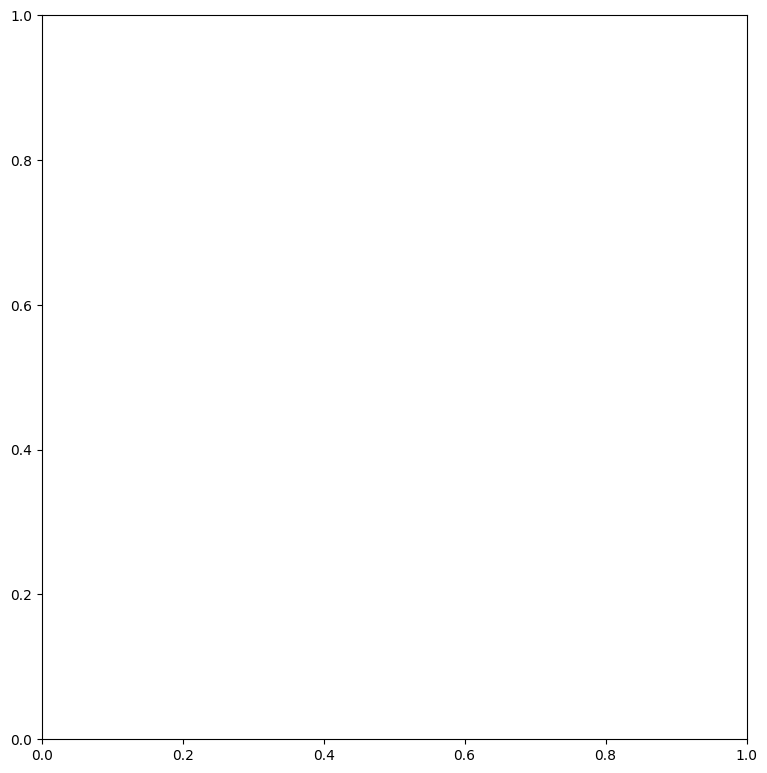

In [3]:
# generating subhalo location and mass vs time gifs!

from matplotlib.animation import FuncAnimation, PillowWriter
from PIL import Image, ImageSequence
import glob
import re

base_dir = "C:/Users/steph/Symphony"
suite_list = ["SymphonyCluster"]
image_directory = "subhalo_gif/*.png"
output_gif_path = "subhalo_animation.gif"

fig, ax = plt.subplots(ncols = 1, nrows = 1, figsize = (8, 8))

for suite_index, suite_name in enumerate(suite_list):
    n_hosts = symlib.n_hosts(suite_name)
    
    for i_host in range(1):
        sim_dir = symlib.get_host_directory(base_dir, suite_name, i_host)
        scale_factors = symlib.scale_factors(sim_dir)
        h, hist = symlib.read_subhalos(sim_dir)

        for snap_index, snap in enumerate(scale_factors):
            host = h[0, snap_index]
            symlib.plot_circle(ax, host["x"][0], host["x"][1], host["rvir"], c = "tab:red")
            
            z0_radius = 100
        
            for i in range(1, len(h)):
                sub = h[i, snap_index]
                if sub["ok"]:
                    symlib.plot_circle(ax, sub['x'][0], sub['x'][1], sub['rvir'], c = "tab:blue", lw = 1.5)

            ax.set_xlim(-7*host["rvir"], 7*host["rvir"])
            ax.set_ylim(-7*host["rvir"], 7*host["rvir"])                            
            #ax.set_xlim(-3000, 3000)
            #ax.set_ylim(-3000, 3000)
            
            ax.set_title(f'a = {(snap):2f}')
            plt.tight_layout()
            
            output_directory = "subhalo_gif"
            filename = f"subhalo_image_{snap_index}.png"
            
            if not os.path.exists(output_directory):
                os.makedirs(output_directory)
                
            full_path = os.path.join(output_directory, filename)
            plt.savefig(full_path, dpi = 100, facecolor = 'white')

            if snap_index < len(scale_factors):
                print(snap_index + 1, len(scale_factors))
                ax.clear()

In [4]:
from matplotlib.animation import FuncAnimation, PillowWriter
from PIL import Image, ImageSequence
import glob
import re

image_directory = "subhalo_gif/*.png"
output_gif_path = "subhalo_animation.gif"

image_paths = glob.glob(image_directory)
image_paths = sorted(glob.glob(image_directory), key=lambda x: int(re.search(r"(\d+)", x).group()))
 
# Load images 
images = []
for path in image_paths:
    img = Image.open(path)
    images.append(img)

if images:
    images[0].save(output_gif_path, save_all=True, append_images=images[1:], duration = 75, loop=0)
    print(f"GIF created and saved at {output_gif_path}")
else:
    print("No images found in the specified directory.")

GIF created and saved at subhalo_animation.gif
